# Download and prepare `SW_IN` (2004-2025)

**notebook version**: `9` (28 Jul 2026)

## ℹ️ About this notebook

Downloads screened `SW_IN` from InfluxDB, merges the three sources into one continuous series,
corrects the 2012 logger faults and the nighttime sensor offset, gap-fills, and writes the product
to the external data folder.

**Output columns:**

- `SW_IN_T1_47_1_gfXG` — the gap-filled series (W m⁻², complete, non-negative)
- `FLAG_SW_IN_T1_47_1_ISFILLED` — `0` = measured, `>0` = filled (codes in `FLAG_LEGEND` below)

**Fill quality is not uniform.** 2004-2018 has two radiation drivers, NABEL on the same tower and
MeteoSwiss Lägern 2.5 km away; 2019-2025 has only Lägern. Both are filled from real measurements,
but the later period leans on the more distant sensor.

Downloading uses diive's `InfluxIO`, which needs `influxdb-client`; `uv sync` installs it here via
the `diive[db]` extra.

***

## 📇 Data sources

**Series**

- `SW_IN_T1_47_1` — ETH, 47 m. **This is the product series.** mst (2005-2021), diive (2022-2025)
- `SW_IN_NABEL_T1_49_1` — NABEL, 49 m, same tower. 2004-2018 only. Gap-filling driver
- `SW_IN_LAE_MS` — MeteoSwiss Lägern, 2.5 km, 845 m. 2004-2025. Gap-filling driver, read from
  the product written by `10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb`

Both drivers are used as measured. Gap-filling is XGBoost; potential radiation and timestamp
features are added by the gap-filler itself.

**Legend**

- NABEL ... [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), meteoscreening with [diive](https://github.com/holukas/diive)
- mst ... ETH data, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... ETH data, meteoscreening with diive

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files: needed e.g. for connection to database
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'  # Expected resolution; TimestampSanitizer raises if the data disagree
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# Output: data files live in the external (untracked) data folder, with the same
# numeric prefix as this notebook.
OUTNAME = "01_METEO_SW_IN_GAPFILLED_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Reference: MeteoSwiss Lägern, 2.5 km from the tower on the same ridge. Produced by
# 10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb. Addressed by path, so a move breaks this read.
REFPATH = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\workflow\10_METEO\10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet")
REFCOL = "SW_IN_LAE_MS"

# --- Inputs for the acquisition-change section -------------------------------------------------
# The site maintenance record, exported from GIN. It lives BESIDE the workflow folder, not inside
# it, because it is an input to many stages rather than the output of one.
FIELDBOOK = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv")

# Every logger program on disk that measures this sensor. Read rather than quoted, so the sensor
# identity and the calibration constants are re-derived on every run. The three CR10X programs are
# all the surviving tower programs that carry the CNR1; the earlier ones of 2004 do not measure
# incoming shortwave at all, and none survives between May 2006 and the CR1000 program of 2016.
PROGRAMS_BEFORE = [
    r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
    r"\csi_loggerscripts\LAEGEREN.20050818.CSI",
    r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
    r"\csi_loggerscripts\LAEGEREN.20050914.CSI",
    r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
    r"\csi_loggerscripts\LAEGEREN.20060524.csi",
]
PROGRAM_AFTER = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
                 r"\logger_scripts\ch-lae_idl_t1_47_1-Version_20160118\CH-LAE_iDL_T1_47_1.CR1")


### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import html
import re
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-29 00:10:52
diive version: v0.91.0


In [3]:
# Result flags of SWINGapFillerXGBoost, see the class docstring.
FLAG_LEGEND = {
    0: '0 = observed',
    1: '1 = daytime gap, filled by the XGBoost model',
    2: '2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)',
    3: '3 = nighttime gap, set to zero by physics',
    4: '4 = daytime gap, filled by clearness-index interpolation',
}

### Captions


In [4]:
# Captions. Every table and every figure in this notebook carries one, so that a reader meeting a
# number in the rendered page can tell what it is without reading the code that produced it.
# Defined here, above the first cell that calls either. Copied as-is from notebook 02.
def tabcap(text, width=100):
    """Print a table caption, above the table it belongs to."""
    print(textwrap.fill(f"Table - {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn.

    A figure with a layout engine makes room for a caption itself. The heatmaps diive builds have
    no engine, and a caption placed in one lands on top of the tick labels; for those the figure
    is extended downwards and every axes moved up by the same amount, so the drawing keeps its
    size and position and the caption gets a free strip below it.
    """
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure - {text}", width)
    # An engine that still lays the figure out at draw time can make room for a caption itself.
    # plt.tight_layout() does NOT leave one: it executes once and leaves a PlaceHolderLayoutEngine
    # that never runs again, so a caption handed to supxlabel there lands on top of the tick
    # labels. Those figures take the manual branch below.
    _engine = fig.get_layout_engine()
    if _engine is not None and type(_engine).__name__ != 'PlaceHolderLayoutEngine':
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12          # inches; one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')


### Plot helpers

In [5]:
# Diagnostic plots for the gap-filling runs. Defined once, used after every run.
#
# Each helper writes its own caption, built from the arguments and the data it was given rather
# than passed in as text. A second call site therefore cannot arrive without a caption, and one
# whose period or column changes cannot keep a caption describing the old one. Same rule as
# plot_product() in notebook 99.

def plot_gapfill_panels(results, label, ylabel=r'$\mathrm{W\ m^{-2}}$', figsize=(16, 7)):
    """Three stacked panels: measured only, the final series, and the fills on their own.

    The third panel is the one to look at. Fills are shown against a blank background, so
    a fill that sits at the wrong level, or a block of fills where there should be none,
    is immediately visible instead of being hidden under the measured series.
    """
    gapfilled = results.gapfilled
    flag = results.flag
    _plotdf = pd.DataFrame({
        'observed': gapfilled.where(flag == 0),
        'gapfilled': gapfilled,
        'gap values': gapfilled.where(flag > 0),
    })
    axs = _plotdf.plot(subplots=True, figsize=figsize, x_compat=True, alpha=.9,
                       title=f"{label}: measured, gap-filled, fills only", legend=True)
    for ax in axs:
        ax.set_ylabel(ylabel)
    plt.tight_layout()
    fig = axs[0].get_figure()
    figcap(fig, f"{label}. Top: the measured records alone, so the gaps are visible as gaps. "
                f"Middle: the exported series, complete. Bottom: only the "
                f"{int((flag > 0).sum()):,} filled records "
                f"({100 * (flag > 0).mean():.1f} % of this period), drawn against a blank "
                f"background - a fill at an implausible level, or a block of fills where there "
                f"should be none, is visible here and nowhere else.")
    return fig


def fill_stats_by_year(flag, label, legend=None):
    """Records per year and flag, plus a stacked bar chart of the filled ones."""
    legend = legend or FLAG_LEGEND
    tab = (pd.crosstab(flag.index.year, flag)
             .rename(columns=lambda f: legend.get(f, f))
             .rename_axis(index='year', columns=None))
    filled = tab.drop(columns=[c for c in tab.columns if str(c).startswith('0 =')],
                      errors='ignore')
    if not filled.empty and filled.to_numpy().sum() > 0:
        ax = filled.plot(kind='bar', stacked=True, figsize=(14, 4),
                         title='Filled records per year')
        ax.set_ylabel('records')
        ax.legend(fontsize=8)
        plt.tight_layout()
        _worst = filled.sum(axis=1).idxmax()
        _totals = filled.sum(axis=1)
        _quiet = int((_totals < 100).sum())
        _first = flag.index[flag == 0][0]
        _pre = int(((flag.index < _first) & (flag.index.year == _worst)).sum())
        figcap(ax.get_figure(),
               f"filled records per year and method for {label}, measured records omitted so the "
               f"fills are readable. The most heavily filled year is {_worst} with "
               f"{int(_totals.max()):,} filled records, of which {_pre:,} precede the first "
               f"measured record. The fills are otherwise confined to a handful of outage years: "
               f"{_quiet} of the {len(_totals)} years carry fewer than a hundred filled records "
               f"each, and several carry none at all.")
    tabcap(f"records per year and provenance code for {label}. Every record carries a code, so "
           f"the rows sum to the number of half-hours in each year")
    return tab


def plot_fill_overview(series, flag, label, ylabel=r'$\mathrm{W\ m^{-2}}$'):
    """Four-panel overview of the final series: where the fills are and how they behave.

    Panels: flag over date/time-of-day; monthly means of the full series against the
    measured-only series (a gap between the two lines means the fills are biased);
    and the share of filled records per month.
    """
    fig = plt.figure(figsize=(18, 9), dpi=100, layout='constrained')
    gs = gridspec.GridSpec(2, 2, figure=fig)
    fig.suptitle(f'Gap-filling overview: {label}', fontsize=15)

    ax = fig.add_subplot(gs[:, 0])
    dv.plotting.HeatmapDateTime(series=flag.astype(float)).plot(
        ax=ax, cb_digits_after_comma=0, zlabel='flag',
        format_style=dv.plotting.FormatStyle(title='Flag (0 = measured)', title_fontsize=11))

    measured = series.where(flag == 0)
    ax = fig.add_subplot(gs[0, 1])
    series.resample('MS').mean().plot(ax=ax, label='all records', lw=1.2)
    measured.resample('MS').mean().plot(ax=ax, label='measured only', lw=1.2, ls='--')
    ax.set_title('Monthly means', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[1, 1])
    share = (flag > 0).resample('MS').mean() * 100
    ax.fill_between(share.index, share.values, step='mid', alpha=.7)
    ax.set_title('Share of filled records per month', fontsize=11)
    ax.set_ylabel('%')

    _gap = (series.resample('MS').mean() - measured.resample('MS').mean()).abs().max()
    figcap(fig, f"where the fills of {label} sit in the record and how they behave. Left: the "
                f"provenance code by date and time of day - the nighttime-zero code draws the "
                f"dark band that follows the seasons, and any daytime fill stands out against "
                f"it. Top right: monthly means of the complete series against the measured "
                f"records alone. The two lines part by at most "
                f"{_gap:.1f} W m-2 in any month; a systematic separation would mean the fills "
                f"are biased relative to the measurements. Bottom right: the share of each month "
                f"that is filled, which is where the 2004-2005 pre-record period and the 2012 "
                f"faults appear.")
    return fig


def plot_pred_vs_measured(model, label, unit=r'$\mathrm{W\ m^{-2}}$'):
    """Predicted against measured on the HELD-OUT test set, plus residuals.

    This is the only honest validation view available: `gapfilled` equals the measurement
    wherever the flag is 0, so plotting those against each other would just draw the 1:1
    line. `daytime_model_.traintest_details_` keeps the test records the model never saw
    during training, which is what these panels use.

    Left: measured vs predicted, 1:1 line in red. Right: residual against prediction —
    a tilt means bias, a widening cone means the error scales with magnitude.
    """
    if model is None:
        print("No model available (no daytime gaps) - nothing to validate.")
        return
    test = model.traintest_details_['test_df']
    measured = test[model.target_col].values
    predicted = model.model_.predict(test.drop(columns=model.target_col))
    residual = predicted - measured
    rmse = float(np.sqrt((residual ** 2).mean()))
    bias = float(residual.mean())

    fig, axs = plt.subplots(ncols=2, figsize=(13, 5.5), dpi=100, layout='constrained')
    fig.suptitle(f"{label} daytime model  (held-out test set, n={len(test):,})", fontsize=13)

    axs[0].hexbin(measured, predicted, gridsize=60, mincnt=1, bins='log', cmap='viridis')
    lim = [float(min(measured.min(), predicted.min())), float(max(measured.max(), predicted.max()))]
    axs[0].plot(lim, lim, 'r-', lw=1.2, label='1:1')
    axs[0].set_xlabel(f'measured {unit}')
    axs[0].set_ylabel(f'predicted {unit}')
    axs[0].set_title(f'RMSE {rmse:.2f}   bias {bias:+.2f}', fontsize=11)
    axs[0].legend(fontsize=8)

    axs[1].hexbin(predicted, residual, gridsize=60, mincnt=1, bins='log', cmap='viridis')
    axs[1].axhline(0, color='r', lw=1.2)
    axs[1].set_xlabel(f'predicted {unit}')
    axs[1].set_ylabel(f'residual (predicted - measured) {unit}')
    axs[1].set_title('Residuals', fontsize=11)
    figcap(fig, f"the {label} daytime model against the {len(test):,} records held out of its "
                f"own training, which is the only view here that is not partly a restatement of "
                f"the fit - everywhere the flag is 0 the gap-filled series equals the "
                f"measurement, so plotting those against each other would draw the 1:1 line and "
                f"say nothing. Left: predicted against measured, with the 1:1 line; RMSE "
                f"{rmse:.1f} W m-2 and bias {bias:+.2f} W m-2. Right: the residual against the "
                f"prediction. A tilt would mean the model is biased at one end of the range; the "
                f"widening cone is expected, because a radiation error scales with the value.")
    return fig


def plot_feature_importances(results, label, top=12):
    """The drivers the model actually used, as a bar chart rather than only a table.

    A gap-filling model that leans almost entirely on the timestamp features is filling with
    climatology, whatever its scores say. This is the view that shows it at a glance.
    """
    imp = results.feature_importances.copy()
    _col = next((c for c in ('PERM_IMPORTANCE', 'IMPORTANCE', 'importance')
                 if c in imp.columns), imp.columns[0])
    imp = imp.sort_values(_col, ascending=False).head(top).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 0.42 * len(imp) + 1.6), dpi=100, layout='constrained')
    ax.barh(imp.index.astype(str), imp[_col], color='#1565C0')
    ax.set_xlabel(_col)
    ax.set_title(f'Driver importance: {label}', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    _top_name = str(imp.index[-1])
    figcap(fig, f"the {min(top, len(imp))} most important drivers of the {label} daytime model, "
                f"ranked by {_col}. The strongest is {_top_name}. What matters here is whether a "
                f"real radiation measurement leads: a model that leans mainly on the timestamp "
                f"features is producing climatology rather than weather, whatever its held-out "
                f"scores say.")
    return fig

### 🔌 Connect to database

In [6]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## ⬇️ `NABEL` data (2004-2018) and ETH data (2022-2025) from `diive` meteoscreening

### Download

In [7]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['SW_IN_NABEL_T1_49_1', 'SW_IN_T1_47_1']
MEASUREMENTS = ['SW']
START = '2004-01-01 00:00:01'
STOP = '2026-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_diive'

nabel_eth_diive_swin_2004_2018_2022_2025, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['SW_IN_NABEL_T1_49_1', 'SW_IN_T1_47_1'] 
from measurements ['SW'], data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 
2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 2 variables:

CPU times: total: 3.3 s
Wall time: 5.54 s


In [8]:
nabel_eth_diive_swin_2004_2018_2022_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_END,,
2004-01-01 00:30:00,NaN,0.0
2004-01-01 01:00:00,NaN,0.0
2004-01-01 01:30:00,NaN,0.0
2004-01-01 02:00:00,NaN,0.0
2004-01-01 02:30:00,NaN,0.0
...,...,...
2025-12-31 22:00:00,0.0,NaN
2025-12-31 22:30:00,0.0,NaN
2025-12-31 23:00:00,0.0,NaN


### Sanitize timestamp

In [9]:
nabel_eth_diive_swin_2004_2018_2022_2025 = TimestampSanitizer(
    data=nabel_eth_diive_swin_2004_2018_2022_2025,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,  # raises ValueError if the data are not 30MIN
).get()
nabel_eth_diive_swin_2004_2018_2022_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


***

## ⬇️ Data from `mst` meteoscreening (2004-2021)

### Download

In [10]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['SW_IN_T1_47_1']
MEASUREMENTS = ['SW']
START = '2004-01-01 00:00:01'
STOP = '2022-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_mst'

mst_swin_2004_2021, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['SW_IN_T1_47_1'] from measurements ['SW'], 
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 2.66 s
Wall time: 4.86 s


In [11]:
mst_swin_2004_2021

,SW_IN_T1_47_1
TIMESTAMP_END,
2005-09-14 11:30:00,0.000000
2005-09-14 12:00:00,25.692612
2005-09-14 13:30:00,645.754150
2005-09-14 14:00:00,314.615936
2005-09-14 14:30:00,220.304276
...,...
2021-12-31 22:00:00,-9.935194
2021-12-31 22:30:00,-10.250348
2021-12-31 23:00:00,-9.810373


### Sanitize timestamp

In [12]:
mst_swin_2004_2021 = TimestampSanitizer(
    data=mst_swin_2004_2021,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,  # raises ValueError if the data are not 30MIN
).get()
mst_swin_2004_2021

,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-14 11:15:00,0.000000
2005-09-14 11:45:00,25.692612
2005-09-14 12:15:00,NaN
2005-09-14 12:45:00,NaN
2005-09-14 13:15:00,645.754150
...,...
2021-12-31 21:45:00,-9.935194
2021-12-31 22:15:00,-10.250348
2021-12-31 22:45:00,-9.810373


***

## ❇️ Merge data

ETH data from `diive` meteoscreening (2022-2025) are the main data, gaps before 2022 are
filled in from the `mst` meteoscreening.

In [13]:
# Merge data on index
swin_2004_2025 = nabel_eth_diive_swin_2004_2018_2022_2025.copy()
swin_2004_2025['SW_IN_T1_47_1'] = swin_2004_2025['SW_IN_T1_47_1'].combine_first(mst_swin_2004_2021['SW_IN_T1_47_1'])
swin_2004_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


### Sanitize timestamp

In [14]:
swin_2004_2025 = TimestampSanitizer(data=swin_2004_2025, output_middle_timestamp=True).get()
swin_2004_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


### Heatmap

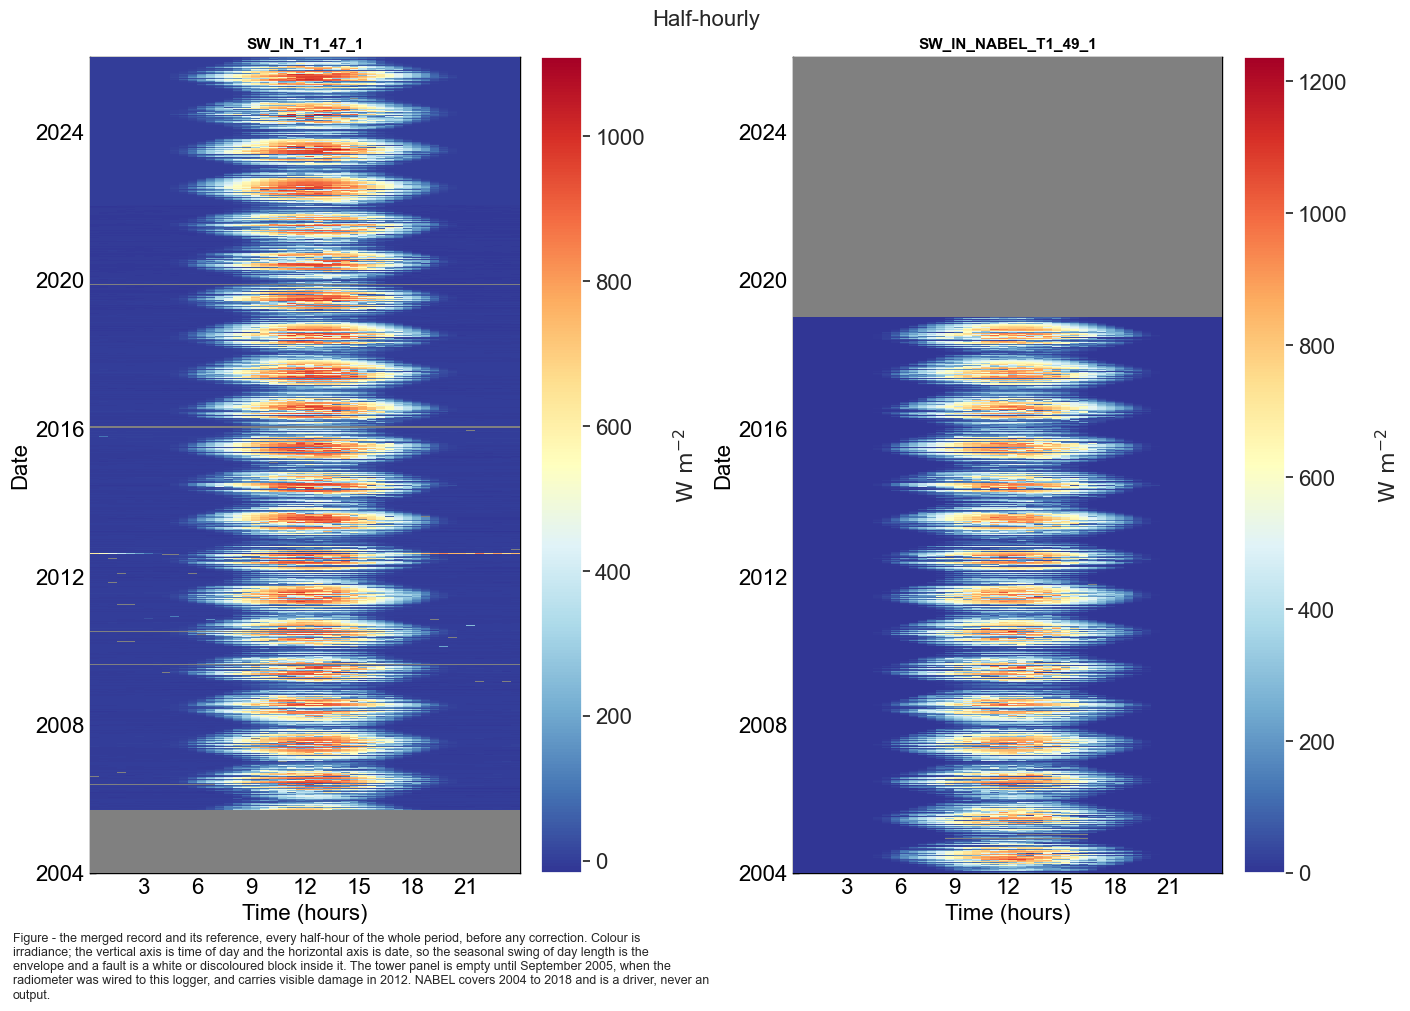

In [15]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=swin_2004_2025['SW_IN_T1_47_1']).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_T1_47_1", title_fontsize=11))
dv.plotting.HeatmapDateTime(series=swin_2004_2025['SW_IN_NABEL_T1_49_1']).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_NABEL_T1_49_1", title_fontsize=11))
figcap(fig, "the merged record and its reference, every half-hour of the whole period, before "
            "any correction. Colour is irradiance; the vertical axis is time of day and the "
            "horizontal axis is date, so the seasonal swing of day length is the envelope and a "
            "fault is a white or discoloured block inside it. The tower panel is empty until "
            "September 2005, when the radiometer was wired to this logger, and carries visible "
            "damage in 2012. NABEL covers 2004 to 2018 and is a driver, never an output.")

### Where the record comes from

Three sources overlap in this frame and none of them covers it alone. The figure below is the
answer to "which measurement stands behind this half-hour", asked of every half-hour, before any
correction or fill has been applied.

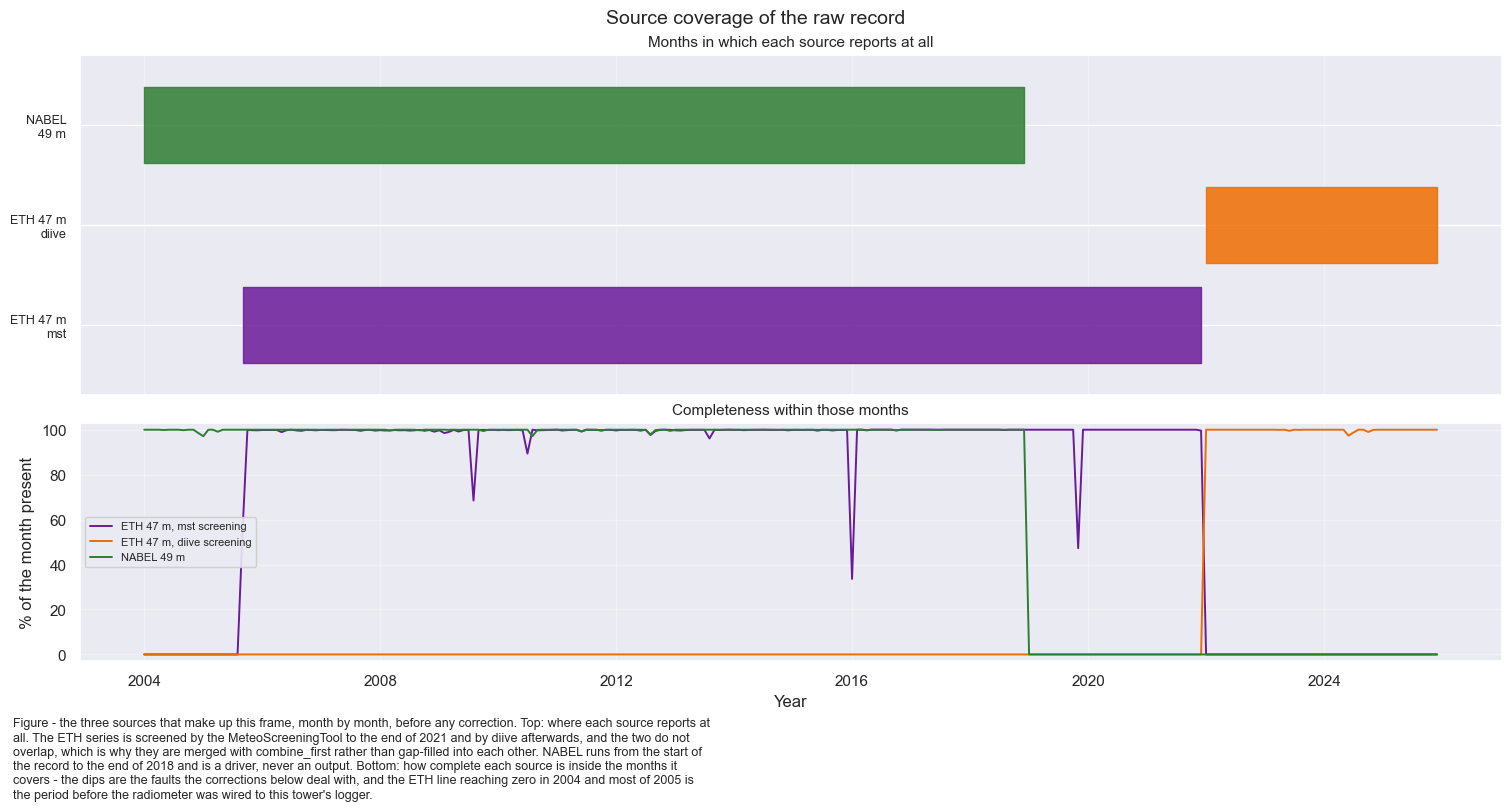

In [16]:
# Which source covers which part of the record, and how completely. Drawn from the two downloads
# as they arrived, so this is the raw availability the rest of the notebook has to work with.
_avail = pd.DataFrame({
    'ETH 47 m, diive screening': nabel_eth_diive_swin_2004_2018_2022_2025['SW_IN_T1_47_1'].notna(),
    'ETH 47 m, mst screening': mst_swin_2004_2021['SW_IN_T1_47_1'].reindex(
        swin_2004_2025.index).fillna(False).astype(bool),
    'NABEL 49 m': swin_2004_2025['SW_IN_NABEL_T1_49_1'].notna(),
}, index=swin_2004_2025.index)
_avail['ETH 47 m, mst screening'] = mst_swin_2004_2021['SW_IN_T1_47_1'].reindex(
    swin_2004_2025.index).notna()
_monthly = _avail.resample('MS').mean() * 100

fig, axs = plt.subplots(nrows=2, figsize=(15, 8), dpi=100, layout='constrained',
                        height_ratios=[2, 1.4], sharex=True)
fig.suptitle('Source coverage of the raw record', fontsize=14)

for _i, (_name, _colour) in enumerate([('ETH 47 m, mst screening', '#6A1B9A'),
                                       ('ETH 47 m, diive screening', '#EF6C00'),
                                       ('NABEL 49 m', '#2E7D32')]):
    _present = _monthly[_name] > 0
    axs[0].fill_between(_monthly.index, _i - 0.38, _i + 0.38,
                        where=_present, color=_colour, alpha=0.85, step='mid')
axs[0].set_yticks(range(3))
# The row labels name the sources, so no legend is needed on this panel - one there sat
# across the lower panel's title.
axs[0].set_yticklabels(['ETH 47 m\nmst', 'ETH 47 m\ndiive', 'NABEL\n49 m'], fontsize=9)
axs[0].set_ylim(-0.7, 2.7)
axs[0].set_title('Months in which each source reports at all', fontsize=11)
axs[0].grid(axis='x', alpha=0.3)

for _name, _colour in [('ETH 47 m, mst screening', '#6A1B9A'),
                       ('ETH 47 m, diive screening', '#EF6C00'),
                       ('NABEL 49 m', '#2E7D32')]:
    axs[1].plot(_monthly.index, _monthly[_name], color=_colour, lw=1.4, label=_name)
axs[1].set_ylabel('% of the month present')
axs[1].set_xlabel('Year')
axs[1].set_ylim(-3, 103)
axs[1].set_title('Completeness within those months', fontsize=11)
axs[1].grid(alpha=0.3)
axs[1].legend(fontsize=8, loc='center left', framealpha=0.9)

figcap(fig, "the three sources that make up this frame, month by month, before any correction. "
            "Top: where each source reports at all. The ETH series is screened by the "
            "MeteoScreeningTool to the end of 2021 and by diive afterwards, and the two do not "
            "overlap, which is why they are merged with combine_first rather than gap-filled "
            "into each other. NABEL runs from the start of the record to the end of 2018 and is a "
            "driver, never an output. Bottom: how complete each source is inside the months it "
            "covers - the dips are the faults the corrections below deal with, and the ETH line "
            "reaching zero in 2004 and most of 2005 is the period before the radiometer was "
            "wired to this tower's logger.")

***

## ✴️ Corrections

### Timestamp shift in August 2012
**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

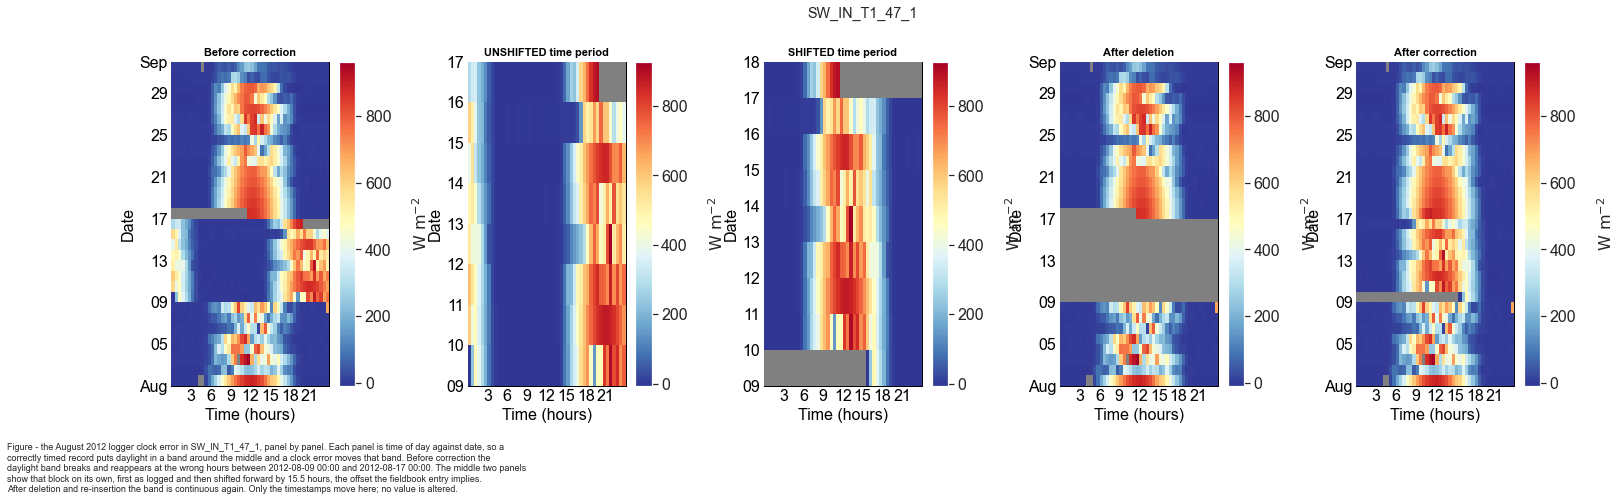

In [17]:
AFFECTED_VARS = ['SW_IN_T1_47_1']
_df = swin_2004_2025.copy()

for av in AFFECTED_VARS:
    fig = plt.figure(figsize=(24, 6), dpi=72)
    fig.suptitle(f"{av}")
    gs = gridspec.GridSpec(1, 5)  # rows, cols
    gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
    ax_before = fig.add_subplot(gs[0, 0])
    ax_unshifted = fig.add_subplot(gs[0, 1])
    ax_shifted = fig.add_subplot(gs[0, 2])
    ax_after = fig.add_subplot(gs[0, 3])
    ax_corrected = fig.add_subplot(gs[0, 4])

    # Show time period around issue, before correction
    _show_locs = (_df.index >= '2012-08-01 00:00') & (_df.index <= '2012-09-01 00:00')
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_before, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="Before correction", title_fontsize=11))

    # Get shifted time period
    _series_corrected = _df.loc[_show_locs, av].copy()
    # Identify shifted time period
    ISSUE_START = '2012-08-09 00:00'
    ISSUE_END = '2012-08-17 00:00'
    _shifted_locs = (_df.index >= ISSUE_START) & (_df.index <= ISSUE_END)
    _series_shifted = _df.loc[_shifted_locs, av].copy()
    _series_shifted = _series_shifted.dropna()
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_unshifted, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="UNSHIFTED time period", title_fontsize=11))

    # Shift SW_IN by 15.5 hours during shifted time period, create corrected time series
    _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=15.5)
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_shifted, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="SHIFTED time period", title_fontsize=11))

    # Delete data between start of issue and the last timestamp of shifted data
    _overwrite_locs = (_df.index >= ISSUE_START) & (_df.index <= _series_shifted.index[-1])
    _df.loc[_overwrite_locs, av] = np.nan
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_after, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="After deletion", title_fontsize=11))

    # Fill in corrected values
    _df.loc[_overwrite_locs, av] = _series_shifted
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_corrected, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="After correction", title_fontsize=11))

    figcap(fig, f"the August 2012 logger clock error in {av}, panel by panel. Each panel is time "
                f"of day against date, so a correctly timed record puts daylight in a band around "
                f"the middle and a clock error moves that band. Before correction the daylight "
                f"band breaks and reappears at the wrong hours between {ISSUE_START} and "
                f"{ISSUE_END}. The middle two panels show that block on its own, first as logged "
                f"and then shifted forward by 15.5 hours, the offset the fieldbook entry implies. "
                f"After deletion and re-insertion the band is continuous again. Only the "
                f"timestamps move here; no value is altered.")

In [18]:
swin_2004_2025 = _df.copy()
swin_2004_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


### Power failure, late July to mid August 2012

The timestamp shift above is not the only problem in August 2012. Aligning `SW_IN_T1_47_1`
against the NABEL sensor day by day, and searching for the time lag that agrees best, gives:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-07-28 | 0 | 37 | 37 |
| 2012-07-31 | 0 | 70 | 70 |
| 2012-08-02 | 0 | 156 | 156 |
| 2012-08-06 | -25.0 h | 181 | 208 |
| 2012-08-09 | -32.5 h | 116 | 467 |
| **2012-08-10** | **+15.5 h** | **60** | 565 |
| **2012-08-14** | **+15.5 h** | **42** | 503 |
| **2012-08-16** | **+15.5 h** | **55** | 420 |
| 2012-08-17 | -24.5 h | 122 | 249 |
| 2012-08-18 | 0 | 8 | 8 |

Two different faults:

- **10 to 16 August** locks onto exactly `+15.5 h` and the error collapses from ~500 to 42-60
  W m-2. That is the logger clock, and the correction above fixes it.
- **29 July to 9 August** degrades steadily (RMSE 57 -> 70 -> 134 -> 156 -> 467) and **no time
  shift repairs it**. The apparent best lags there are around +/-24 h, which are aliases: shifting
  a daily cycle by about a day roughly realigns it, and even then the error only falls to 115-230
  W m-2 rather than to the 42-60 seen in the genuine shift window. 17 August is likewise
  transitional.

The fieldbook gives the cause, and dates the repair to the day the degradation ends:

> **09.08.2012** Fixed the power problem on the tower: replaced battery and replaced some fuses
> (there were many falsely placed or broken) and replaced the whole power supply
>
> **10.08.2012** Some problems remain with logger, maybe it's the WLAN (could not log in the last
> two weeks), restared programs

"could not log in the last two weeks" puts the onset around 27 July, which matches the 29 July
seen in the data. `TA_T1_47_1`, a different instrument on the same acquisition system, degrades
over the same window (RMSE 1.2-3.2 degC against a 0.7-0.9 degC baseline) and is likewise not
repaired by any constant lag — consistent with a supply fault upstream of both sensors rather
than with either sensor failing.

Those records cannot be repaired, only removed. Over 29 July to 9 August the daytime mean is
309 W m-2 at 47 m against 402 W m-2 at NABEL, individual half-hours differ by up to 933 W m-2,
and the error does not even keep a consistent sign: on 2 August the daytime mean is 188 against
374 at NABEL, while on 6 August it is 194 against 126. Left in place these would enter the
product labelled as measured. They are therefore deleted here and gap-filled afterwards from
the two radiation drivers.

All windows below are given on the **corrected** time axis. The first runs to 10 August 15:30
rather than to 9 August, because the shift moves the questionable 9 August readings forward by
15.5 h; the second covers the untrustworthy tail after the last shifted value; the third is the
October-November period described next.
### Storm damage, late October to early November 2012

A third damaged period, found by the same day-by-day lag search:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-10-27 | 0 | 6.4 | 6.4 |
| 2012-10-28 | 0 | 143.3 | 143.3 |
| 2012-10-30 | 0 | 214.4 | 214.4 |
| 2012-11-05 | -3.0 h | 177.1 | 182.3 |
| 2012-11-08 | 0 | 71.4 | 71.4 |
| 2012-11-10 | 0 | 15.6 | 15.6 |

Shifting in time barely helps on any day here — where a lag does come out lowest the gain is a
few hundredths — so unlike August this is not a clock problem. The fieldbook records storm damage
and cable work in exactly this window:

> **01.11.2012** Checked Forestfloor and Hut for broken sensors due to fallen trees and big branches
>
> **06.11.2012** checked all sensor cables. especialy the cables at the forest floor are sometimes
> strongly stressed. tried to unstress the cables

The data return to normal from 10 November, right after that visit. Note that both entries name
the *forest floor* sensors rather than the 47 m instruments, so the link is circumstantial: what
is certain is that a storm hit the site, that cables were found stressed, and that the recovery
follows the repair visit. `SW_IN_T1_47_1` and `TA_T1_47_1` are affected together over the same
days, which again points at something shared rather than at one instrument.

The fieldbook also notes on **30.10.2012** that the MOXA was "running on wrong time base: CEST
instead of CET", fixed at 10:11 that day. Swiss daylight saving ended on 28 October, so
timestamps could have been an hour ahead for those two days — but no such offset is detectable
in the data (it would show as a best lag of -2 records, and it does not), and in any case the
whole period is removed below.

The affected records are deleted together with the August ones.

Removed 1214 degraded records from SW_IN_T1_47_1 (gap-filled later from NABEL).


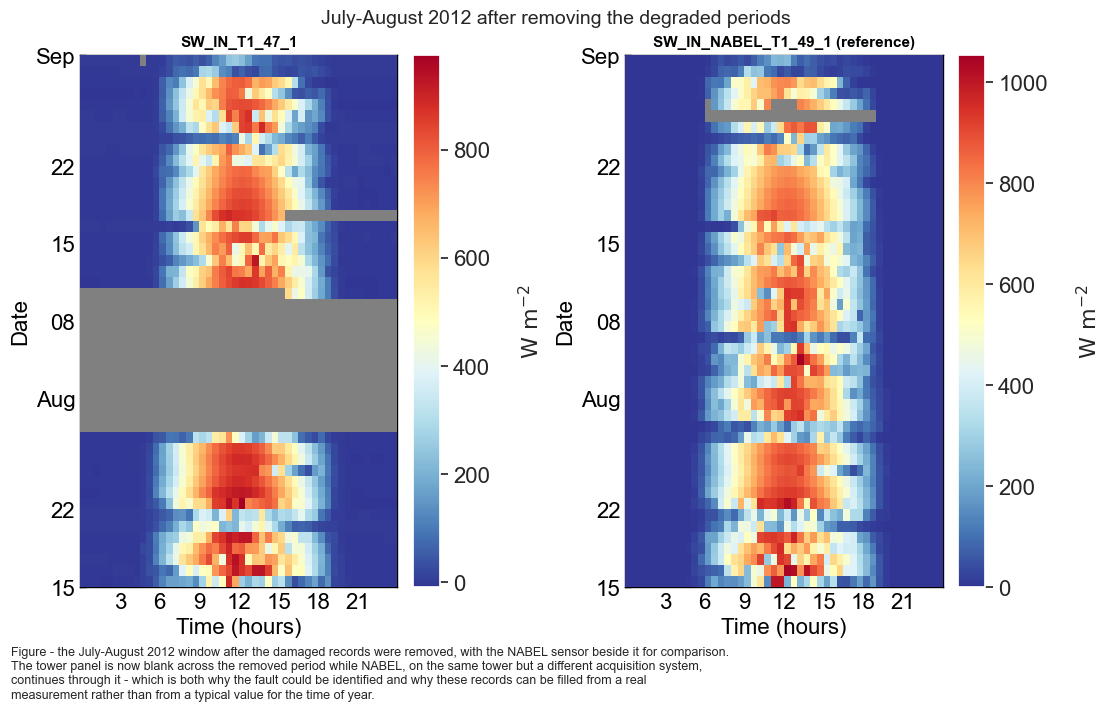

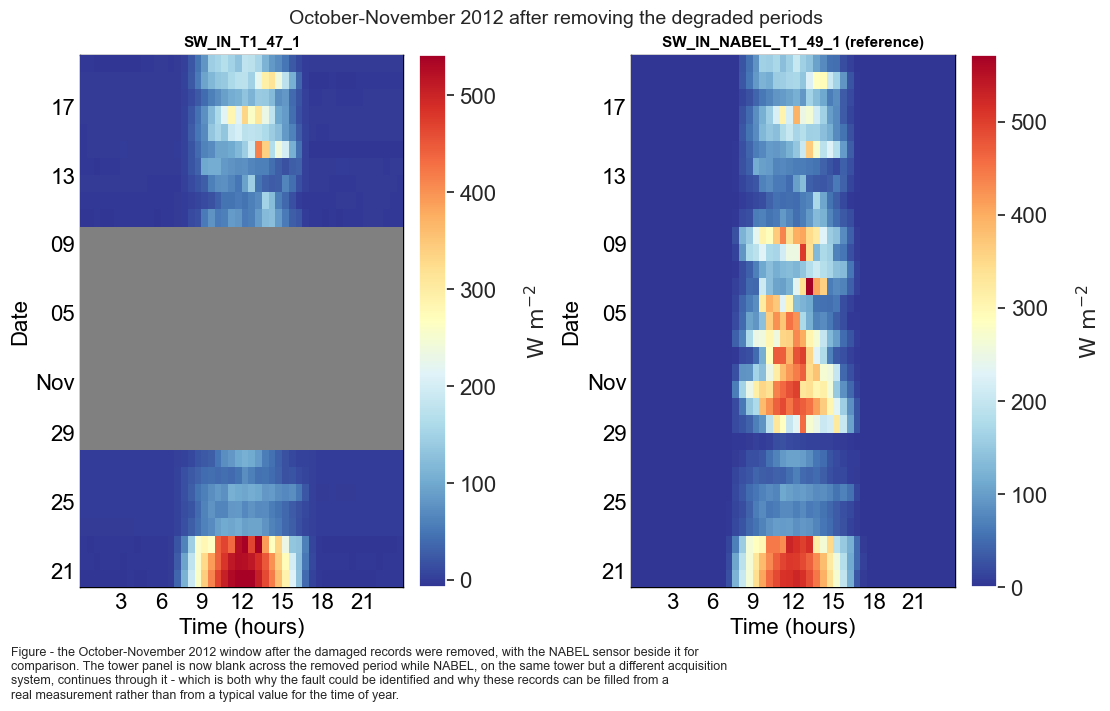

In [19]:
# Three damaged periods in 2012, all documented in the fieldbook and none repairable.
# Windows are on the CORRECTED time axis (i.e. after the +15.5 h shift above).
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-08-17 15:30', '2012-08-18 00:00'),  # transitional tail after the last shifted value
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]
DEGRADED_VAR = 'SW_IN_T1_47_1'

_before = int(swin_2004_2025[DEGRADED_VAR].notna().sum())
for _start, _end in BAD_WINDOWS_2012:
    _locs = (swin_2004_2025.index >= _start) & (swin_2004_2025.index <= _end)
    swin_2004_2025.loc[_locs, DEGRADED_VAR] = np.nan
_removed = _before - int(swin_2004_2025[DEGRADED_VAR].notna().sum())
print(f"Removed {_removed} degraded records from {DEGRADED_VAR} (gap-filled later from NABEL).")

# One heatmap pair per affected period, with the NABEL sensor as the reference.
for _lo, _hi, _label in [('2012-07-15', '2012-09-01', 'July-August'),
                         ('2012-10-20', '2012-11-20', 'October-November')]:
    fig, axs = plt.subplots(ncols=2, figsize=(11, 7), dpi=100, layout="constrained")
    fig.suptitle(f'{_label} 2012 after removing the degraded periods', fontsize=14)
    _show = (swin_2004_2025.index >= _lo) & (swin_2004_2025.index <= _hi)
    dv.plotting.HeatmapDateTime(series=swin_2004_2025.loc[_show, DEGRADED_VAR]).plot(
        ax=axs[0], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title=DEGRADED_VAR, title_fontsize=11))
    dv.plotting.HeatmapDateTime(series=swin_2004_2025.loc[_show, 'SW_IN_NABEL_T1_49_1']).plot(
        ax=axs[1], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title='SW_IN_NABEL_T1_49_1 (reference)', title_fontsize=11))
    figcap(fig, f"the {_label} 2012 window after the damaged records were removed, with the NABEL "
                f"sensor beside it for comparison. The tower panel is now blank across the "
                f"removed period while NABEL, on the same tower but a different acquisition "
                f"system, continues through it - which is both why the fault could be identified "
                f"and why these records can be filled from a real measurement rather than from a "
                f"typical value for the time of year.")

### Nighttime zero-offset correction

A pyranometer reads a small non-zero signal at night. It is an instrument offset, not radiation,
and it drifts, so it is removed per day rather than as one constant. `mst`-screened records carry
a clearly negative offset.

It is done here rather than left to the gap-filler because `correct_nighttime_offset=True`
corrects only the series being filled — its **target**. Series passed through `context_df` are
used as given, and both radiation sensors are drivers. Correcting once, here, covers every use.

::: {.callout-warning title="This correction writes into gaps — capture the mask first"}
`remove_nighttime_zero_offset()` forces **every** nighttime position to zero, `NaN` included. On a
gappy series it therefore fills nighttime gaps with a real value, and every later step reads them
as measured. That is the trap notebook `03` fell into, where it turned 7,543 modelled values into
apparently measured ones.

So the gap mask is taken **before** the correction and restored **after**: the offset goes, a gap
stays a gap.
:::

In [20]:
# Correct both radiation sensors. Lägern is not corrected here -- it is published by
# MeteoSwiss already offset-free (its minimum is exactly 0.0) and we do not alter reference data.
ZERO_OFFSET_VARS = ['SW_IN_T1_47_1', 'SW_IN_NABEL_T1_49_1']

_summary = []
NZO_BEFORE = {}   # the uncorrected series, kept so the figure below can show what was removed
NZO_RESULTS = {}  # the diagnostics object per sensor, likewise
for _var in ZERO_OFFSET_VARS:
    _series = swin_2004_2025[_var]
    NZO_BEFORE[_var] = _series.copy()

    # Capture the gap mask BEFORE correcting: the correction writes zeros into
    # nighttime NaNs and would otherwise turn gaps into apparent measurements.
    _gaps_before = _series.isna()

    _res = dv.corrections.nighttime_zero_offset_diagnostics(
        series=_series,
        lat=SITE_LAT,
        lon=SITE_LON,
        utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    )
    NZO_RESULTS[_var] = _res

    _corrected = _res.corrected.copy()
    _corrected[_gaps_before] = np.nan  # restore the gaps the correction just filled

    # The correction must not have invented or destroyed data.
    assert _corrected.isna().equals(_gaps_before), f'{_var}: gap structure changed'

    swin_2004_2025[_var] = _corrected
    _summary.append({
        'variable': _var,
        'n_gaps': int(_gaps_before.sum()),
        'below_zero_before': _res.n_below_zero_before,
        'below_zero_before_night': _res.n_below_zero_before_night,
        'below_zero_after': int((_corrected < 0).sum()),
        'offset_min': round(float(_res.offset.min()), 3),
        'offset_max': round(float(_res.offset.max()), 3),
    })

tabcap("what the nighttime zero-offset correction removed from each sensor. `below_zero_before` "
       "counts the negative readings the uncorrected series carried and `below_zero_after` those "
       "left; the offset range shows how far the correction varies over the record, which is why "
       "it is applied per day rather than as one constant")
pd.DataFrame(_summary).set_index('variable')

Table - what the nighttime zero-offset correction removed from each sensor. `below_zero_before`
counts the negative readings the uncorrected series carried and `below_zero_after` those left; the
offset range shows how far the correction varies over the record, which is why it is applied per day
rather than as one constant



,n_gaps,below_zero_before,below_zero_before_night,below_zero_after,offset_min,offset_max
variable,,,,,,
SW_IN_T1_47_1,34002,133876,128454,0,-13.467,18.690
SW_IN_NABEL_T1_49_1,122954,0,0,0,0.000,0.184


#### Check: nighttime is zero and nothing is negative

The correction is only useful if it actually held, so it is asserted rather than assumed. Both
conditions are checked on measured records only — gaps are still gaps at this point and are filled
later.

In [21]:
# Rebuild the day/night split independently of the correction, from the site coordinates,
# so this is a real check and not a restatement of what the correction just did.
_dnf = dv.variables.DaytimeNighttimeFlag(
    timestamp_index=swin_2004_2025.index,
    nighttime_threshold=0.001,
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)
_is_night = _dnf.get_nighttime_flag() == 1
print(f"Nighttime records: {int(_is_night.sum()):,} of {len(swin_2004_2025):,}")

for _var in ZERO_OFFSET_VARS:
    _s = swin_2004_2025[_var]
    _measured = _s.notna()
    _night_vals = _s[_is_night & _measured]
    _n_negative = int((_s[_measured] < 0).sum())
    _n_night_nonzero = int((_night_vals != 0).sum())
    print(f"  {_var:<24s} negatives: {_n_negative:>6,}   nighttime non-zero: {_n_night_nonzero:>6,}")
    assert _n_negative == 0, f'{_var}: {_n_negative} negative values remain after correction'
    assert _n_night_nonzero == 0, f'{_var}: {_n_night_nonzero} nighttime values are not zero'

print("\nOK: no negatives, and every measured nighttime record is exactly zero.")

Nighttime records: 184,260 of 385,728
  SW_IN_T1_47_1            negatives:      0   nighttime non-zero:      0
  SW_IN_NABEL_T1_49_1      negatives:      0   nighttime non-zero:      0

OK: no negatives, and every measured nighttime record is exactly zero.


#### Plot: what the offset correction removed

The table gives the range of the offset; it does not say whether the offset drifts, when it is
worst, or how large it is next to the daytime signal it sits on top of. All three matter, because
an offset that is stable could be removed as a constant and one that is not cannot.

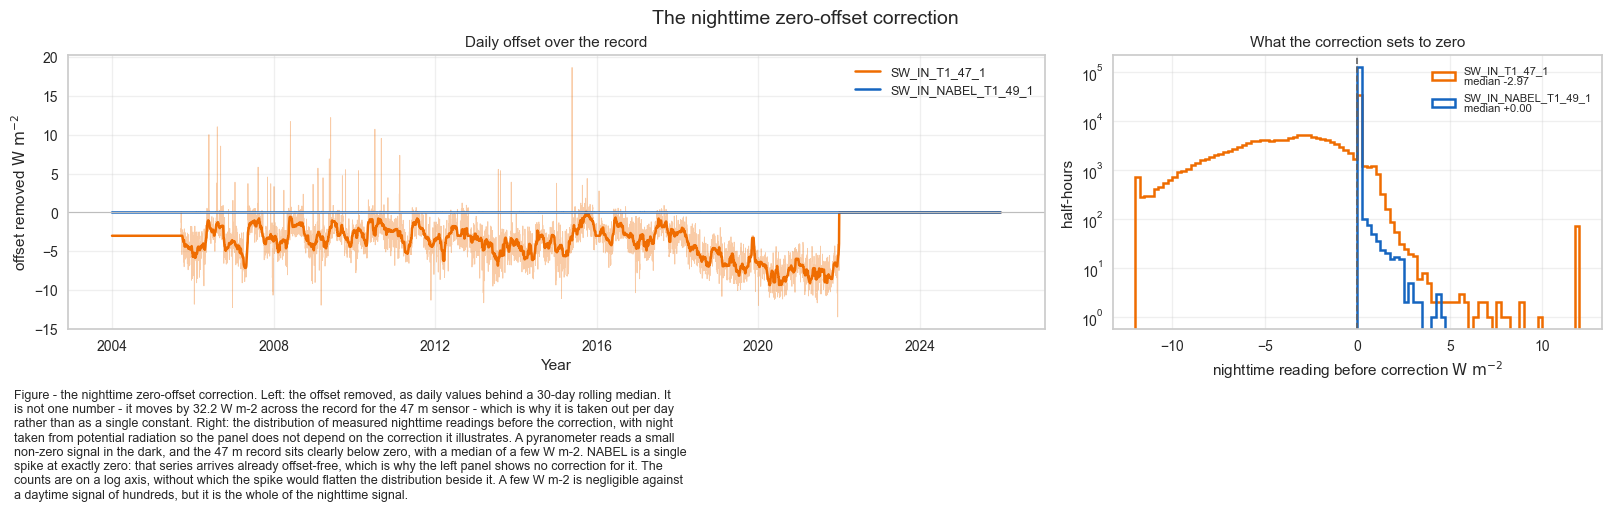

In [22]:
# The correction, drawn. Left: the daily offset over the record, per sensor. Right: the
# distribution of measured nighttime readings before the correction, which is the quantity the
# correction sets to zero.
fig, axs = plt.subplots(ncols=2, figsize=(16, 5), dpi=100, layout='constrained',
                        width_ratios=[2, 1])
fig.suptitle('The nighttime zero-offset correction', fontsize=14)

for _var, _colour in [('SW_IN_T1_47_1', '#EF6C00'), ('SW_IN_NABEL_T1_49_1', '#1565C0')]:
    _off = NZO_RESULTS[_var].offset.resample('D').mean().dropna()
    axs[0].plot(_off.index, _off, color=_colour, lw=0.6, alpha=0.35)
    axs[0].plot(_off.index, _off.rolling(30, center=True, min_periods=10).median(),
                color=_colour, lw=1.8, label=_var)
axs[0].axhline(0, color='#BDBDBD', lw=0.8)
axs[0].set_xlabel('Year')
axs[0].set_ylabel(r'offset removed $\mathrm{W\ m^{-2}}$')
axs[0].set_title('Daily offset over the record', fontsize=11)
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=9)

# Night from potential radiation, so this panel does not depend on the correction it illustrates.
_potrad_nzo = dv.variables.potrad(timestamp_index=swin_2004_2025.index, lat=SITE_LAT,
                                  lon=SITE_LON, utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
_night_nzo = _potrad_nzo <= 0
_bins = np.linspace(-12, 12, 97)
for _var, _colour in [('SW_IN_T1_47_1', '#EF6C00'), ('SW_IN_NABEL_T1_49_1', '#1565C0')]:
    _vals = NZO_BEFORE[_var][_night_nzo].dropna()
    axs[1].hist(_vals.clip(_bins[0], _bins[-1]), bins=_bins, histtype='step', lw=1.8,
                color=_colour, label=f"{_var}\nmedian {_vals.median():+.2f}")
axs[1].axvline(0, color='#616161', lw=1.2, ls='--')
axs[1].set_yscale('log')
axs[1].set_xlabel(r'nighttime reading before correction $\mathrm{W\ m^{-2}}$')
axs[1].set_ylabel('half-hours')
axs[1].set_title('What the correction sets to zero', fontsize=11)
axs[1].grid(alpha=0.3)
axs[1].legend(fontsize=8)

_span = float(NZO_RESULTS['SW_IN_T1_47_1'].offset.max() - NZO_RESULTS['SW_IN_T1_47_1'].offset.min())
figcap(fig, "the nighttime zero-offset correction. Left: the offset removed, as daily values "
            "behind a 30-day rolling median. It is not one number - it moves by "
            f"{_span:.1f} W m-2 across the record for the 47 m sensor - which is why it is taken "
            "out per day rather than as a single constant. Right: the distribution of measured "
            "nighttime readings before the correction, with night taken from potential radiation "
            "so the panel does not depend on the correction it illustrates. A pyranometer reads a "
            "small non-zero signal in the dark, and the 47 m record sits clearly below zero, "
            "with a "
            "median of a few W m-2. NABEL is a single spike at exactly zero: that series "
            "arrives already offset-free, which is why the left panel shows no correction "
            "for it. The counts are on a log axis, without which the spike would flatten "
            "the distribution beside it. A few W m-2 is negligible against a daytime signal "
            "of hundreds, but it is the whole of the nighttime signal.")

### Dataframe

In [23]:
tabcap("the merged frame after the 2012 corrections and the nighttime offset removal, and its summary statistics. The counts differ between columns because the three series cover different periods")
display(swin_2004_2025)
swin_2004_2025.describe()

Table - the merged frame after the 2012 corrections and the nighttime offset removal, and its
summary statistics. The counts differ between columns because the three series cover different
periods



,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
count,351726.000000,262774.000000
mean,145.103354,140.035108
std,239.663239,233.702051
min,0.000000,0.000000
25%,0.000000,0.000000
50%,3.677069,2.495635
75%,195.487633,186.456335
max,1118.658439,1236.721293


***

***
## 🌍 Reference: MeteoSwiss Lägern

`SW_IN` is the position of the sun multiplied by the state of the sky. `SW_IN_POT` and the
timestamp give the first factor exactly; only a second radiation measurement gives the second.
NABEL was that measurement, and it **stops in 2018**.

MeteoSwiss Lägern is 2.5 km from the tower on the same ridge at 845 m and covers the whole record,
so it is a driver in both gap-filling runs and the only one after 2018.

It is a **driver, not a replacement**: it never overwrites a measured value, and the exported
series is always the tower sensor.

::: {.callout-note title="Timestamp conversion"}
The reference carries `TIMESTAMP_END`; this notebook works on `TIMESTAMP_MID`. For 30MIN data the
bin `(t-30min, t]` has its midpoint at `t-15min`, so the reference index is shifted back by 15
minutes. The guard below proves the alignment instead of assuming it.
:::

In [24]:
swin_ref = pd.read_parquet(REFPATH)[[REFCOL]]
print(f"Reference read: {len(swin_ref):,} records, "
      f"{swin_ref.index[0]} -> {swin_ref.index[-1]} ({swin_ref.index.name})")

# TIMESTAMP_END -> TIMESTAMP_MID: the 30MIN bin (t-30min, t] has its midpoint at t-15min.
swin_ref.index = swin_ref.index - pd.Timedelta(minutes=15)
swin_ref.index.name = swin_2004_2025.index.name

# Guard: the shift must be right. Correlating the reference against the *measured* tower series
# at several half-hour offsets has to pick offset 0. A silently mis-shifted driver would teach
# the model the wrong sky state and there would be nothing in the output to show it.
_meas = swin_2004_2025['SW_IN_T1_47_1']
_scores = {}
for _off in (-1, 0, 1):
    _j = pd.concat([_meas.rename('t'), swin_ref[REFCOL].shift(_off).rename('r')], axis=1).dropna()
    _j = _j[_j['r'] > 20]  # daytime only: at night both are ~0 and carry no timing information
    _scores[_off] = _j['t'].corr(_j['r'])
    print(f"  offset {_off:+d} x 30min: daytime corr {_scores[_off]:.4f}")
assert max(_scores, key=_scores.get) == 0, f"reference is mis-aligned: {_scores}"
print("OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.")

swin_2004_2025 = swin_2004_2025.join(swin_ref, how='left')
print(f"\nMerged. {REFCOL} available for "
      f"{swin_2004_2025[REFCOL].notna().mean() * 100:.2f}% of records "
      f"({swin_2004_2025[REFCOL].isna().sum():,} missing)")
tabcap("the tower series and the MeteoSwiss reference side by side. Both are half-hourly means over the same index, so the difference in the record count is the difference in coverage")
swin_2004_2025[['SW_IN_T1_47_1', REFCOL]].describe().round(2)

Reference read: 384,241 records, 2004-02-01 01:00:00 -> 2026-01-01 01:00:00 (TIMESTAMP_END)
  offset -1 x 30min: daytime corr 0.9288
  offset +0 x 30min: daytime corr 0.9648


  offset +1 x 30min: daytime corr 0.9069
OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.

Merged. SW_IN_LAE_MS available for 99.58% of records (1,602 missing)
Table - the tower series and the MeteoSwiss reference side by side. Both are half-hourly means over
the same index, so the difference in the record count is the difference in coverage



,SW_IN_T1_47_1,SW_IN_LAE_MS
count,351726.00,384126.00
mean,145.10,141.51
std,239.66,231.39
min,0.00,0.00
25%,0.00,2.00
50%,3.68,5.33
75%,195.49,189.33
max,1118.66,1155.33


#### Plot: what the two drivers actually offer

`describe()` says the three series cover a similar range. It does not say how tightly each
reference tracks the tower half-hour by half-hour, which is what determines how good a fill from
it can be — and the two references differ in exactly that.

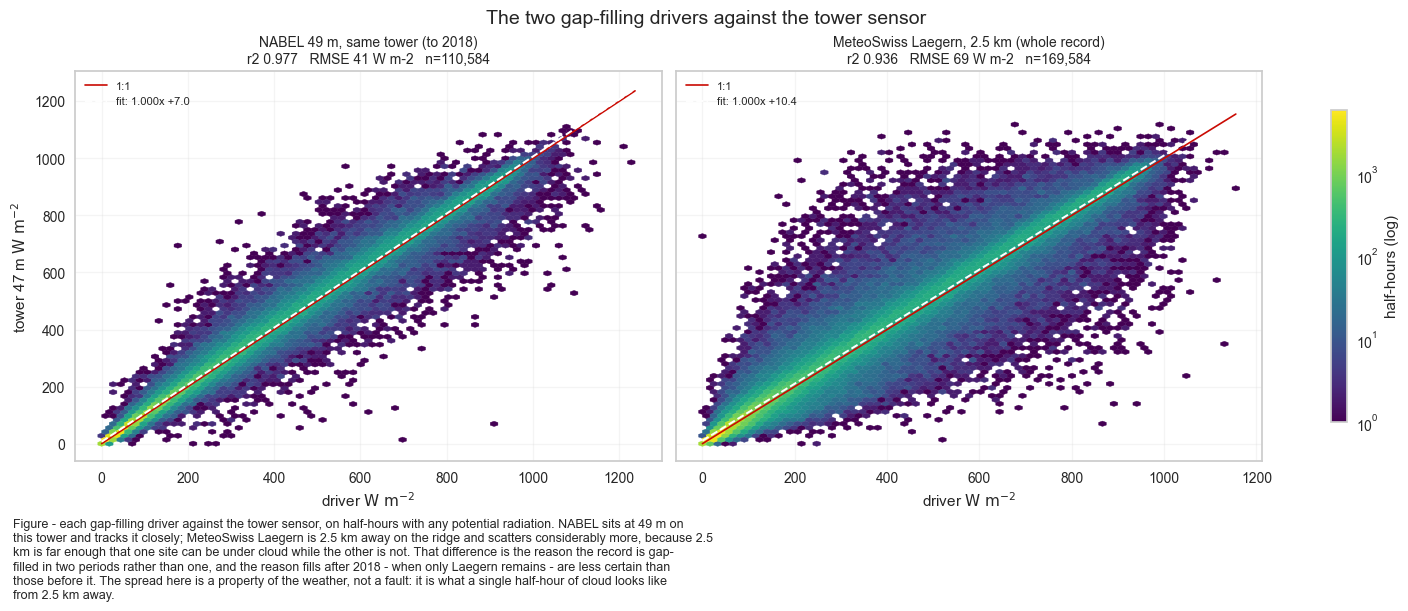

In [25]:
# Each driver against the tower sensor on well-lit half-hours. The 1:1 line and the fitted slope
# say how much of a fill's quality comes from the driver rather than from the model.
_potrad_ref = dv.variables.potrad(timestamp_index=swin_2004_2025.index, lat=SITE_LAT,
                                  lon=SITE_LON, utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
_lit_ref = _potrad_ref > 50

fig, axs = plt.subplots(ncols=2, figsize=(14, 6), dpi=100, layout='constrained', sharey=True)
fig.suptitle('The two gap-filling drivers against the tower sensor', fontsize=14)

for _ax, _driver, _label in [
        (axs[0], 'SW_IN_NABEL_T1_49_1', 'NABEL 49 m, same tower (to 2018)'),
        (axs[1], REFCOL, 'MeteoSwiss Laegern, 2.5 km (whole record)')]:
    _j = swin_2004_2025.loc[_lit_ref, ['SW_IN_T1_47_1', _driver]].dropna()
    _hb = _ax.hexbin(_j[_driver], _j['SW_IN_T1_47_1'], gridsize=70, mincnt=1, bins='log',
                     cmap='viridis')
    _lim = [0, float(max(_j.max()))]
    _ax.plot(_lim, _lim, 'r-', lw=1.2, label='1:1')
    _slope, _icpt = np.polyfit(_j[_driver].to_numpy(), _j['SW_IN_T1_47_1'].to_numpy(), 1)
    _ax.plot(_lim, [_slope * _x + _icpt for _x in _lim], color='w', lw=1.4, ls='--',
             label=f'fit: {_slope:.3f}x {_icpt:+.1f}')
    _r2 = _j[_driver].corr(_j['SW_IN_T1_47_1']) ** 2
    _rmse = float(np.sqrt(((_j['SW_IN_T1_47_1'] - _j[_driver]) ** 2).mean()))
    _ax.set_title(f"{_label}\nr2 {_r2:.3f}   RMSE {_rmse:.0f} W m-2   n={len(_j):,}", fontsize=10)
    _ax.set_xlabel(r'driver $\mathrm{W\ m^{-2}}$')
    _ax.legend(fontsize=8, loc='upper left')
    _ax.grid(alpha=0.2)
axs[0].set_ylabel(r'tower 47 m $\mathrm{W\ m^{-2}}$')
fig.colorbar(_hb, ax=axs, label='half-hours (log)', shrink=0.8)

figcap(fig, "each gap-filling driver against the tower sensor, on half-hours with any potential "
            "radiation. NABEL sits at 49 m on this tower and tracks it closely; MeteoSwiss "
            "Laegern is 2.5 km away on the ridge and scatters considerably more, because 2.5 km "
            "is far enough that one site can be under cloud while the other is not. That "
            "difference is the reason the record is gap-filled in two periods rather than one, "
            "and the reason fills after 2018 - when only Laegern remains - are less certain than "
            "those before it. The spread here is a property of the weather, not a fault: it is "
            "what a single half-hour of cloud looks like from 2.5 km away.")

***

## 🔎 The 2016 acquisition change, and what the two references are worth

On 21 January 2016 the tower's data logger was replaced, and notebook `02` established that
`TA_T1_47_1` steps by about 1.3 °C across that changeover. The same acquisition system carries
`SW_IN_T1_47_1`, so the question of whether this series moved as well has to be answered rather
than assumed. **It did not**, and this section records what establishes that, so the question is
settled in the notebook rather than re-opened.

A negative result is only worth as much as the evidence behind it, so the same scan is run over
the whole record rather than at one candidate year. Doing so turns up two changes that are real,
neither of them at 2016, and both of them matter to this notebook:

1. **the sensor and its calibration did not change in 2016** — every logger program on disk
   applies the same conversion to the same instrument;
2. **the data show no step at the changeover** — smaller than the threshold at which this scan counts an
   event, and than the same measurement's own worst ordinary year;
3. **the NABEL sensor is a second instrument**, not this one recorded twice — which is what makes
   it usable as a driver and as the reference the 2012 correction above was dated against;
4. **MeteoSwiss Lägern stepped by about 5 % in October 2010** — the reference station, not the
   tower. It is a gap-filling driver here, so this is a property of this product's inputs;
5. **the radiometer itself was replaced in December 2021**, CNR1 to CNR4 — the hardware change
   that does matter for this variable, and it did not move the series either;
6. **the tower sensor departs from both references by about 3 % from 2013**, with no documented
   cause. It is not corrected, and it is stated rather than left to be found.

The full four-sensor attribution, including the co-located PAR sensor as a third tower-side
witness, is in `RADIATION_SENSOR_CONTINUITY.ipynb`. This section carries only what bears on the
product built here, together with the assertions that keep it true.


### Helpers for this section

The logger programs and the maintenance record are read in the notebook rather than quoted, so
that a re-run re-derives the argument instead of inheriting a stale copy of it. Both are signed by
the people who did the work and this notebook renders to a public page, so every string taken out
of either passes through the same redaction used in notebooks `02` and `08`.


In [26]:

# --- Fieldbook and logger-script redaction ----------------------------------------------------
# The GIN export and the logger programs both name people. This notebook renders to a public page,
# so every string taken out of either passes through redact_people() at the single point where it
# is flattened. Same map and same rules as notebooks 02 and 08; the map lives beside the export,
# OUTSIDE this repository, so the repo never carries a real name.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')


def unmapped_report_path(label: str) -> Path:
    """Where the unmapped-name candidates of one audit are written.

    Per label, because this notebook audits two sources: a single shared file would let the
    second audit overwrite the first one's findings.
    """
    _slug = re.sub(r'[^a-z0-9]+', '_', label.lower()).strip('_')
    return Path(FIELDBOOK).with_name(f'redact_unmapped_{_slug}.txt')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map.

    Raises if the map is missing. That is the point: carrying on with redaction quietly disabled
    prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the redaction map is missing: {path}. Without it the names these files record would "
            f"print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()
# Longest surface form first, so a bare surname cannot corrupt a double-barrelled one that starts
# with it. Lookarounds rather than \b, because some forms end in an initial.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped name with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


def strip_html(text) -> str:
    """Flatten one GIN fieldbook entry to plain text, with the people it names redacted."""
    flat = html.unescape(re.sub(r'<[^>]+>', ' ', str(text)))
    return redact_people(re.sub(r'\s+', ' ', flat).strip())


_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+(' + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Candidates are never printed - an
    exception message is stored in a notebook like any other output - so they go to a file beside
    the map and only the count is shown.
    """
    allow = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in allow:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        _report = unmapped_report_path(label)
        if write_report:
            _report.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {_report}. Add the people to redact_names.csv and the "
            f"technical terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(allow)} allowlisted terms)")
    return 0


def program_excerpt(path, pattern: str, before: int = 6, after: int = 4, expect: int = 1) -> str:
    """The lines of a logger program around `pattern`, redacted.

    Only the matched instruction is returned, never the file header: these programs are signed by
    their authors. Raises unless the pattern matches exactly `expect` times. Both directions
    matter: no match reads as 'the program does not measure this', and an over-broad pattern
    quietly prints the wrong instruction next to the argument it is supposed to support.
    """
    lines = Path(path).read_text(encoding='latin-1').splitlines()
    blocks = []
    for i, line in enumerate(lines):
        if re.search(pattern, line):
            lo, hi = max(0, i - before), min(len(lines), i + after + 1)
            blocks.append('\n'.join(lines[lo:hi]))
    if len(blocks) != expect:
        raise ValueError(f"{Path(path).name}: {pattern!r} matched {len(blocks)} time(s), expected "
                         f"{expect}. The program layout has changed, the wrong file is configured, "
                         f"or the pattern is not specific enough.")
    return redact_people('\n\n'.join(blocks))


def calibration_constants(excerpt: str) -> dict:
    """The multiplier and offset of one measurement instruction, parsed from its own text.

    The two program languages write the same two numbers differently - the CR10X lists them as
    numbered parameters, the CR1000 as positional arguments - so each is matched on its own shape
    and the result compared. Raises if either number cannot be found, because a silently empty
    dict would make the comparison below pass by having nothing to disagree about.
    """
    if 'Mult' in excerpt:                                    # CR10X parameter listing
        mult = re.search(r'^\s*\d+:\s*([\d.]+)\s+Mult', excerpt, re.M)
        offset = re.search(r'^\s*\d+:\s*([\d.]+)\s+Offset', excerpt, re.M)
    else:                                                    # CR1000 VoltDiff(...) call
        call = re.search(r'VoltDiff\s*\(([^)]*)\)', excerpt)
        args = [a.strip() for a in call.group(1).split(',')] if call else []
        mult = re.match(r'([\d.]+)$', args[-2]) if len(args) >= 2 else None
        offset = re.match(r'([\d.]+)$', args[-1]) if len(args) >= 2 else None
    if not (mult and offset):
        raise ValueError("could not parse a multiplier and an offset from the instruction - the "
                         "program language or the layout has changed")
    return {'multiplier': float(mult.group(1)), 'offset': float(offset.group(1))}


In [27]:

# The guards guard. A helper that silently returns nothing is worse than no helper, so every
# failure path is exercised before anything is read.
try:
    program_excerpt(PROGRAM_AFTER, r'ThisPatternIsNotInAnyLoggerProgram')
except ValueError as _exc:
    print(f"OK, program_excerpt raised on a pattern that does not occur: {_exc}")
else:
    raise AssertionError("(!) program_excerpt accepted a pattern that does not occur.")

# 'Ada Lovelace' is nobody at this site, so the control can spell her out without disclosing
# anything - and it writes no report, so the real one is not overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print("OK, the unknown-name net fired on a name that is not in the map")
else:
    raise AssertionError("(!) the unknown-name net did not fire on an unmapped name.")

# And the constant parser must refuse an instruction it cannot read, rather than return an empty
# comparison that would agree with anything.
try:
    calibration_constants("18:  Volt (Diff) (P2) ;Messung von Kin\n 1: 1        Reps")
except ValueError as _exc:
    print(f"OK, calibration_constants raised on an instruction with no constants: {_exc}")
else:
    raise AssertionError("(!) calibration_constants accepted an instruction carrying no constants.")


OK, program_excerpt raised on a pattern that does not occur: CH-LAE_iDL_T1_47_1.CR1: 'ThisPatternIsNotInAnyLoggerProgram' matched 0 time(s), expected 1. The program layout has changed, the wrong file is configured, or the pattern is not specific enough.
OK, the unknown-name net fired on a name that is not in the map
OK, calibration_constants raised on an instruction with no constants: could not parse a multiplier and an offset from the instruction - the program language or the layout has changed


### 1️⃣ The sensor and its calibration did not change

`TA` stepped in 2016 because the sensor **and** its conversion changed together: a Rotronic
MP101A read as an analog voltage at `Mult 0.1` became a Campbell CS215 read over SDI-12 at
multiplier `1`. Shortwave radiation is the opposite case, and the two programs say so directly.

Every program is read here and its two constants parsed out of its own text, so the comparison is
made on every run rather than on the reading someone once made of it.


In [28]:

# Every logger program on disk that measures this sensor, read rather than quoted. The CR10X
# programs are listed oldest first; the CR1000 program is the one installed at the changeover.
CONSTANTS = {}

print("=" * 78)
print("BEFORE 2016: the CR10X programs")
print("=" * 78)
_cr10x_excerpts = []
for _p in PROGRAMS_BEFORE:
    _ex = program_excerpt(_p, r'Messung von Kin', before=5, after=6)
    _cr10x_excerpts.append(_ex)
    CONSTANTS[Path(_p).name] = calibration_constants(_ex)
    print(f"\n--- {Path(_p).name}")
    print(_ex)

print("\n" + "=" * 78)
print(f"AFTER 2016:  {Path(PROGRAM_AFTER).name}")
print("=" * 78)
_cr1000_excerpt = program_excerpt(PROGRAM_AFTER, r'VoltDiff\(SW_IN_T1_47_1', before=5, after=0)
CONSTANTS[Path(PROGRAM_AFTER).name] = calibration_constants(_cr1000_excerpt)
print(_cr1000_excerpt)

# These files are signed by their authors, so they get the same two nets as the fieldbook:
# redaction inside program_excerpt, and the unknown-name audit here.
audit_unmapped_names(_cr10x_excerpts + [_cr1000_excerpt], 'logger programs')

tabcap("the conversion each logger program applied to this sensor's raw voltage. The 2016 "
       "changeover replaced the logger; it did not change either constant")
_const = pd.DataFrame(CONSTANTS).T
_const.index.name = 'logger program'
display(_const)

# The decisive assertion of this step. If the multiplier had changed, SW_IN would step at the
# changeover by construction and the rest of this section would be measuring that.
_mults = {v['multiplier'] for v in CONSTANTS.values()}
_offsets = {v['offset'] for v in CONSTANTS.values()}
print(f"\ndistinct multipliers across all {len(CONSTANTS)} programs: {sorted(_mults)}")
print(f"distinct offsets:    {sorted(_offsets)}")
print(f"implied sensitivity: {1000 / max(_mults):.2f} uV/W/m2 "
      f"(the CNR1 calibration factor named in the programs' own comments)")
assert len(_mults) == 1 and len(_offsets) == 1, (
    "the logger programs do not all apply the same conversion to SW_IN - the argument that the "
    "2016 changeover cannot have moved this series no longer holds")
assert _offsets == {0.0}, "a non-zero offset appeared in a program - re-derive the argument below"


BEFORE 2016: the CR10X programs

--- LAEGEREN.20050818.CSI
;-----------------------------------------------------------------------
; Net Radiometer CNR1 from NABEL-Station,sn: 020484, factor=10.03uV/W/m2
;-----------------------------------------------------------------------


18:  Volt (Diff) (P2) ;Messung von Kin
 1: 1        Reps
 2: 33       25 mV 50 Hz Rejection Range
 3: 3        DIFF Channel
 4: 23       Loc [ Kin       ]
 5: 99.7009  Mult
 6: 0.0      Offset

--- LAEGEREN.20050914.CSI
;-----------------------------------------------------------------------
; Net Radiometer CNR1 from NABEL-Station,sn: 020484, factor=10.03uV/W/m2
;-----------------------------------------------------------------------


18:  Volt (Diff) (P2) ;Messung von Kin
 1: 1        Reps
 2: 33       25 mV 50 Hz Rejection Range
 3: 3        DIFF Channel
 4: 23       Loc [ Kin       ]
 5: 99.7009  Mult
 6: 0.0      Offset

--- LAEGEREN.20060524.csi
;----------------------------------------------------------

,multiplier,offset
logger program,,
LAEGEREN.20050818.CSI,99.7009,0.0
LAEGEREN.20050914.CSI,99.7009,0.0
LAEGEREN.20060524.csi,99.7009,0.0
CH-LAE_iDL_T1_47_1.CR1,99.7009,0.0



distinct multipliers across all 4 programs: [99.7009]
distinct offsets:    [0.0]
implied sensitivity: 10.03 uV/W/m2 (the CNR1 calibration factor named in the programs' own comments)


Both acquisition systems measure **the same physical instrument through the
same calibration**: a Kipp & Zonen CNR1, serial number 020484, on a 25 mV differential channel at
multiplier `99.7009` and offset `0`. That multiplier is `1000 / 10.03`, the reciprocal of the
sensitivity the programs' own comments record, so the two eras convert the same microvolts into
the same watts per square metre. Replacing the logger changed how the voltage was digitised; it
changed nothing about what the voltage meant.

::: {.callout-note title="What the programs cover, and what they do not"}
Three CR10X programs carry this measurement, spanning August 2005 to May 2006, and the CR1000
program dates from January 2016. **No tower program between May 2006 and January 2016 survives on
disk**, so the constants could in principle have changed and changed back within that gap. The
programs establish the two endpoints; the data below cover the interval between them, and show no
change at any point in it.
:::

A second date falls out of the same files. The three CR10X programs of 2004 measure no incoming
shortwave at all — their comments record that the radiometer's channels carried a PAR sensor
"in earlier times" — and the CNR1 instruction first appears in the program dated 14 September 2005.
The tower record should therefore begin then, and it does.


In [29]:

# A second, independent date from the same programs. The three CR10X programs of 2004 measure no
# incoming shortwave at all - their comments record that the radiometer's channels carried a PAR
# sensor "in earlier times" - and the CNR1 measurement first appears in the program dated
# 14 September 2005. The tower record should therefore begin on that day and not before.
RECORD_START = swin_2004_2025['SW_IN_T1_47_1'].dropna().index[0]
_first_prog = min(re.search(r'\.(\d{8})\.', Path(p).name).group(1) for p in PROGRAMS_BEFORE)
_first_prog = pd.Timestamp(_first_prog)
print(f"earliest program carrying the CNR1 measurement: {_first_prog:%d %b %Y}")
print(f"first measured SW_IN_T1_47_1 record:            {RECORD_START:%d %b %Y %H:%M}")
print(f"difference: {(RECORD_START.normalize() - _first_prog).days} day(s)")
assert abs((RECORD_START.normalize() - _first_prog).days) <= 31, (
    "the record does not begin when the sensor was first programmed - one of the two has moved "
    "and the identification of the instrument needs re-checking")


earliest program carrying the CNR1 measurement: 18 Aug 2005
first measured SW_IN_T1_47_1 record:            14 Sep 2005 11:15
difference: 27 day(s)


### 2️⃣ Reading the three sensors against each other

A radiometer's error is **multiplicative**: a sensitivity that is 3 % wrong reads 3 % low at
1000 W m⁻² and 3 % low at 100. Every comparison below is therefore a ratio, never a difference,
and a level change is quoted as a percentage.

Two controls are built into the helper rather than left to each call site, because both were
capable of producing a change that is not a change:

- **Season.** The ratio between two sites has a seasonal cycle, so medians are taken per calendar
  month and averaged over months. A year missing a winter cannot then be compared against one that
  is not. The comparison is further restricted to April-September, where snow and rime on an
  upward-facing sensor cannot act.
- **Illumination.** Only half-hours whose *potential* radiation exceeds 300 W m⁻² enter, and both
  series must exceed 50 W m⁻². Potential radiation is astronomical and so cannot drift, which is
  what makes it a safe selector; at low sun the ratio between two sites is dominated by their
  horizons and by how level the sensors are, and says nothing about calibration.


In [30]:

# Radiation errors are multiplicative, so every comparison below is a RATIO, never a difference.
#
# Two controls are built into the helper rather than left to each call site.
#   Season: a ratio between two stations has a seasonal cycle, so medians are taken per calendar
#     month and then averaged over months. A year that happens to be missing a winter cannot then
#     be compared against one that is not.
#   Illumination: only half-hours with potential radiation above WELL_LIT enter, and both series
#     must exceed MIN_IRRADIANCE. At low sun the ratio is dominated by horizon and levelling
#     differences between two sites and carries no information about calibration.
WELL_LIT = 300.0        # W m-2 of POTENTIAL radiation: astronomical, so it cannot drift
MIN_IRRADIANCE = 50.0   # W m-2 measured, at both stations
SUMMER_MONTHS = [4, 5, 6, 7, 8, 9]

POTRAD = dv.variables.potrad(timestamp_index=swin_2004_2025.index,
                             lat=SITE_LAT, lon=SITE_LON,
                             utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)


def ratio_by_year(num: str, den: str, summer_only: bool = True, min_records: int = 100):
    """Month-matched yearly median of `num`/`den` over well-lit half-hours.

    `summer_only` restricts to April-September. Snow and rime on an upward-facing sensor, and the
    large horizon differences at low sun, both act in winter and both would be read as a
    calibration change; the summer window removes them. The unrestricted version is available so
    that a result can be shown not to depend on the choice.
    """
    _mask = POTRAD > WELL_LIT
    if summer_only:
        _mask = _mask & swin_2004_2025.index.month.isin(SUMMER_MONTHS)
    _j = swin_2004_2025.loc[_mask, [num, den]].dropna()
    _j = _j[(_j[num] > MIN_IRRADIANCE) & (_j[den] > MIN_IRRADIANCE)]
    if len(_j) < min_records * 12:
        raise ValueError(f"{num}/{den}: only {len(_j)} usable half-hours, too few to build "
                         f"monthly medians from")
    _r = _j[num] / _j[den]
    _m = _r.groupby([_r.index.year, _r.index.month]).median()
    _m.index.names = ['year', 'month']
    _n = _r.groupby([_r.index.year, _r.index.month]).count()
    _m = _m[_n >= min_records]
    if _m.empty:
        raise ValueError(f"{num}/{den}: no calendar month reaches {min_records} records")
    return _m.groupby(level=0).mean()


def step_at(series: pd.Series, year: int, span: int = 3) -> float:
    """Percentage change of a yearly ratio across `year`, over `span` years either side.

    The candidate year itself is excluded from both sides: a change that happens inside a year
    belongs to neither era, and including it would halve the step it is meant to measure.
    """
    _pre = series.reindex(range(year - span, year)).dropna()
    _post = series.reindex(range(year + 1, year + 1 + span)).dropna()
    if len(_pre) < 2 or len(_post) < 2:
        return float('nan')
    return 100 * (_post.mean() / _pre.mean() - 1)


In [31]:

# The guards guard, again. Both helpers would otherwise return a plausible number from almost no
# data: ratio_by_year on a window holding a handful of half-hours, step_at on a year the record
# does not reach. ratio_by_year has two separate guards - too little data overall, and enough
# overall but no single month populated - so both are exercised, because a control that only ever
# trips the first would leave the second untested.
for _thresh, _which in [(100_000, 'too few half-hours in total'),
                        (4_000, 'enough in total, but no single calendar month')]:
    try:
        ratio_by_year('SW_IN_T1_47_1', 'SW_IN_NABEL_T1_49_1', min_records=_thresh)
    except ValueError as _exc:
        print(f"OK, ratio_by_year raised on '{_which}': {_exc}")
    else:
        raise AssertionError(f"(!) ratio_by_year accepted a threshold no data can meet ({_which}).")

_probe = ratio_by_year('SW_IN_T1_47_1', REFCOL)
assert np.isnan(step_at(_probe, 1990)), "(!) step_at returned a number for a year off the record"
print("OK, step_at returns nan for a year the record does not cover")


OK, ratio_by_year raised on 'too few half-hours in total': SW_IN_T1_47_1/SW_IN_NABEL_T1_49_1: only 51498 usable half-hours, too few to build monthly medians from
OK, ratio_by_year raised on 'enough in total, but no single calendar month': SW_IN_T1_47_1/SW_IN_NABEL_T1_49_1: no calendar month reaches 4000 records
OK, step_at returns nan for a year the record does not cover


### 3️⃣ The data show no step at the changeover

Three sensors give three pairwise ratios. A calibration change at one of them moves every ratio it
appears in and no other, which is what makes the attribution possible at all — the same argument
notebook `02` makes for `TA`.

The change across 2016 is then measured the same way as the change across every other year of the
record, so that it is judged against this measurement's own variability rather than against zero.


In [32]:

# Every pairwise ratio among the three sensors, year by year. The 2016 changeover is then read off
# them in the same way as any other year in the record, so it is judged against the record's own
# year-to-year variability rather than against zero.
PAIRS = [('tower 47 m / MeteoSwiss', 'SW_IN_T1_47_1', REFCOL),
         ('tower 47 m / NABEL 49 m', 'SW_IN_T1_47_1', 'SW_IN_NABEL_T1_49_1'),
         ('NABEL 49 m / MeteoSwiss', 'SW_IN_NABEL_T1_49_1', REFCOL)]
RATIOS = {_label: ratio_by_year(_a, _b) for _label, _a, _b in PAIRS}
ratio_table = pd.DataFrame(RATIOS)
ratio_table.index.name = 'YEAR'

tabcap("each pairwise ratio year by year, as a percentage of its own 2006-2010 mean. A calibration "
       "change at one sensor moves every ratio that sensor appears in, and no other")
_base = ratio_table.loc[2006:2010].mean()
display((100 * (ratio_table / _base - 1)).round(2))

BREAK_YEAR = 2016
tabcap(f"the change across {BREAK_YEAR} in each ratio, against the largest change the same "
       f"measurement finds anywhere else in the record")
_rows = []
for _label in RATIOS:
    _s = RATIOS[_label]
    _elsewhere = {_y: step_at(_s, _y) for _y in _s.index if _y != BREAK_YEAR}
    _elsewhere = pd.Series(_elsewhere).dropna()
    _rows.append({'pair': _label,
                  f'change across {BREAK_YEAR} (%)': step_at(_s, BREAK_YEAR),
                  'median |change| elsewhere (%)': _elsewhere.abs().median(),
                  'largest |change| elsewhere (%)': _elsewhere.abs().max(),
                  'year of that largest change': int(_elsewhere.abs().idxmax())})
break_table = pd.DataFrame(_rows).set_index('pair')
break_table['year of that largest change'] = break_table['year of that largest change'].astype(int)
display(break_table.round(2))

# The assertion this section exists to make. It is made on the two pairs the TOWER SENSOR appears
# in, and not on the third: the 2016 changeover replaced this tower's logger, so it cannot have
# moved either reference, and NABEL / MeteoSwiss is carried in the table only as the behaviour of
# the two references against each other. Asserting on it would make this section fail for a reason
# it is not about, which it did while this was being written.
TOWER_PAIRS = [_l for _l in RATIOS if _l.startswith('tower')]
assert len(TOWER_PAIRS) == 2, "the pair list has changed - re-check which pairs the assertion covers"

# The threshold is taken from what this measurement does in an ordinary year, not chosen. Two
# stations 2.5 km apart, compared over three-year windows, differ by of order a percent from one
# window to the next for reasons that are neither instrumental nor interesting; a wall set below
# that would fire on no change at all rather than on a change. It is set at 2 %, the same value
# the four-sensor scan in RADIATION_SENSOR_CONTINUITY.ipynb calls an event: comfortably above the
# ordinary-year variability reported in the table above, and well under half the October 2010
# step this same scan finds at the reference station.
EVENT_THRESHOLD = 2.0
assert EVENT_THRESHOLD > break_table['median |change| elsewhere (%)'].max(), (
    "the threshold has fallen below the median change this measurement finds in an ordinary "
    "year, which would make it fire on nothing having happened")

# Two-sided on purpose: the change across 2016 must be below that threshold AND smaller than what
# the same measurement finds at its worst elsewhere. A future re-run that breaks either means the
# series HAS moved, and this section must be re-derived rather than relaxed.
for _label in TOWER_PAIRS:
    _row = break_table.loc[_label]
    _change = _row[f'change across {BREAK_YEAR} (%)']
    print(f"  {_label}: {_change:+.2f} % across {BREAK_YEAR}, against "
          f"{_row['median |change| elsewhere (%)']:.2f} % in a typical year and "
          f"{_row['largest |change| elsewhere (%)']:.2f} % at its worst "
          f"({int(_row['year of that largest change'])})")
    assert abs(_change) < EVENT_THRESHOLD, (
        f"{_label} changes by {_change:.2f} % across {BREAK_YEAR}, past the {EVENT_THRESHOLD} % "
        f"an event is counted at - SW_IN may have moved at the acquisition change after all, and "
        f"this section must be re-derived")
    assert abs(_change) < _row['largest |change| elsewhere (%)'], (
        f"{_label}: the change across {BREAK_YEAR} is now the largest in the record, which is the "
        f"opposite of what this section concludes")
print(f"\nBoth pairs involving the tower sensor change by less than {EVENT_THRESHOLD} % across "
      f"{BREAK_YEAR}, and by less than they change at their worst elsewhere in the record.")


Table - each pairwise ratio year by year, as a percentage of its own 2006-2010 mean. A calibration
change at one sensor moves every ratio that sensor appears in, and no other



,tower 47 m / MeteoSwiss,tower 47 m / NABEL 49 m,NABEL 49 m / MeteoSwiss
YEAR,,,
2004,NaN,NaN,-1.68
2005,1.57,4.49,-2.25
2006,-0.35,0.52,-0.94
2007,-0.43,-0.20,-0.18
2008,-0.69,-0.08,-0.70
2009,0.15,-0.32,0.59
2010,1.31,0.08,1.23
2011,-5.50,-0.58,-5.08
2012,-4.41,-0.56,-4.33


Table - the change across 2016 in each ratio, against the largest change the same measurement finds
anywhere else in the record



,change across 2016 (%),median |change| elsewhere (%),largest |change| elsewhere (%),year of that largest change
pair,,,,
tower 47 m / MeteoSwiss,-0.27,0.82,3.63,2010
tower 47 m / NABEL 49 m,-0.99,1.84,2.90,2013
NABEL 49 m / MeteoSwiss,1.35,1.98,4.91,2011


  tower 47 m / MeteoSwiss: -0.27 % across 2016, against 0.82 % in a typical year and 3.63 % at its worst (2010)
  tower 47 m / NABEL 49 m: -0.99 % across 2016, against 1.84 % in a typical year and 2.90 % at its worst (2013)

Both pairs involving the tower sensor change by less than 2.0 % across 2016, and by less than they change at their worst elsewhere in the record.


### 4️⃣ The NABEL sensor is a second instrument, not this one recorded twice

Both logger programs describe the sensor at 47 m as *"Net Radiometer CNR1 from NABEL-Station"*,
which leaves a real question open: if `SW_IN_NABEL_T1_49_1` were the same physical instrument
recorded by a second acquisition system, it would be no check on anything. Two things above would
then rest on a sensor compared against itself — its use as a gap-filling driver for 2004-2018, and
the 2012 timestamp correction, which was dated against it.

It is a different instrument. The CNR1 at 47 m is the NABEL station's *property*, read by this
tower's logger; NABEL's own sensor sits at 49 m on its own system.


In [33]:

# Is SW_IN_NABEL_T1_49_1 a second instrument, or the same one recorded twice? The programs above
# describe the sensor at 47 m as the NABEL station's own CNR1, which leaves the question open, and
# it matters: a driver that is secretly the target teaches the gap-filler nothing, and the 2012
# timestamp correction above was dated against this series.
_both = swin_2004_2025[['SW_IN_T1_47_1', 'SW_IN_NABEL_T1_49_1']].dropna()
_both = _both[(POTRAD.reindex(_both.index) > WELL_LIT)]
_d = _both['SW_IN_T1_47_1'] - _both['SW_IN_NABEL_T1_49_1']

# The same statistics against MeteoSwiss, which is certainly a different instrument at a different
# place, so the numbers above have something to be read against.
_bm = swin_2004_2025[['SW_IN_T1_47_1', REFCOL]].dropna()
_bm = _bm[(POTRAD.reindex(_bm.index) > WELL_LIT)]
_dm = _bm['SW_IN_T1_47_1'] - _bm[REFCOL]

tabcap("how closely each reference tracks the tower sensor on well-lit half-hours. Two "
       "digitisations of one instrument would agree to within rounding; these do not")
display(pd.DataFrame({
    'NABEL 49 m': {'half-hours compared': len(_both),
                   'correlation': _both.corr().iloc[0, 1],
                   'SD of difference (W m-2)': _d.std(),
                   'agree within 1 W m-2 (%)': 100 * (_d.abs() < 1).mean(),
                   'agree within 5 W m-2 (%)': 100 * (_d.abs() < 5).mean()},
    'MeteoSwiss Laegern': {'half-hours compared': len(_bm),
                           'correlation': _bm.corr().iloc[0, 1],
                           'SD of difference (W m-2)': _dm.std(),
                           'agree within 1 W m-2 (%)': 100 * (_dm.abs() < 1).mean(),
                           'agree within 5 W m-2 (%)': 100 * (_dm.abs() < 5).mean()},
}).round(3))

# The second, independent argument: for more than a year NABEL measures while the tower does not.
# One instrument cannot do that.
_only_nabel = int((swin_2004_2025['SW_IN_NABEL_T1_49_1'].notna()
                   & swin_2004_2025['SW_IN_T1_47_1'].isna()
                   & (POTRAD > WELL_LIT) & (swin_2004_2025.index < RECORD_START)).sum())
print(f"\nwell-lit half-hours measured by NABEL before the tower record begins: {_only_nabel:,}")
print(f"  (the CNR1 was wired to the tower logger on {RECORD_START:%d %b %Y}; NABEL was already "
      f"recording)")

assert 100 * (_d.abs() < 1).mean() < 25, (
    "the tower and NABEL series now agree like two copies of one measurement - if they are the "
    "same instrument, NABEL is not an independent driver and the 2012 correction above rests on "
    "a sensor compared against itself")
assert _only_nabel > 1000, (
    "NABEL no longer covers well-lit half-hours the tower does not - the second argument for two "
    "instruments has gone")
print("Two instruments, on two acquisition systems. NABEL is an independent reference here.")


Table - how closely each reference tracks the tower sensor on well-lit half-hours. Two digitisations
of one instrument would agree to within rounding; these do not



,NABEL 49 m,MeteoSwiss Laegern
half-hours compared,88308.000,135496.000
correlation,0.985,0.959
SD of difference (W m-2),44.973,75.191
agree within 1 W m-2 (%),8.512,2.792
agree within 5 W m-2 (%),27.595,13.764



well-lit half-hours measured by NABEL before the tower record begins: 11,999


  (the CNR1 was wired to the tower logger on 14 Sep 2005; NABEL was already recording)
Two instruments, on two acquisition systems. NABEL is an independent reference here.


### 5️⃣ MeteoSwiss Lägern moved in October 2010; the tower did not

Running the same measurement at every year of the record, rather than only at 2016, finds a change
several times larger than anything at the changeover — and it is not at this site.


In [34]:

# The reference station itself. The scan above is repeated over the whole record rather than at
# one candidate year, so the largest change anywhere is found blind and then attributed.
_scan = pd.DataFrame({_label: {_y: step_at(_s, _y) for _y in _s.index}
                      for _label, _s in RATIOS.items()}).sort_index()
_scan.index.name = 'YEAR'
tabcap("the same three-years-either-side change computed at every year of the record. The largest "
       "entries in the two columns involving MeteoSwiss fall on the same year, and the column "
       "that does not involve it is quiet there")
display(_scan.round(2))

MS_STEP_YEAR = int(_scan['tower 47 m / MeteoSwiss'].abs().idxmax())
print(f"\nlargest change in tower / MeteoSwiss anywhere in the record: {MS_STEP_YEAR}")
for _label in RATIOS:
    print(f"  {_label}: {_scan.loc[MS_STEP_YEAR, _label]:+.2f} %")

# When the reference station's own instrumentation changed, read off the reference file rather
# than asserted: diffuse radiation is a channel MeteoSwiss Laegern did not have before.
_diffuse_start = pd.read_parquet(REFPATH)['SW_IN_DIFF_LAE_MS'].dropna().index[0]
print(f"\nMeteoSwiss Laegern first reports diffuse radiation on {_diffuse_start:%d %b %Y %H:%M}, "
      f"a channel that needs a shading device the station did not previously carry.")

# Both references move together against the tower, and the tower does not move against NABEL.
# That is what puts the change at MeteoSwiss rather than here.
assert _scan.loc[MS_STEP_YEAR, 'NABEL 49 m / MeteoSwiss'] < -2.0, (
    "NABEL no longer steps against MeteoSwiss in the same year as the tower does - the change can "
    "no longer be attributed to the reference station")
assert abs(_scan.loc[MS_STEP_YEAR, 'tower 47 m / NABEL 49 m']) < 1.0, (
    "the tower now steps against NABEL in that year too - the change is not confined to the "
    "reference station and this section must be re-derived")
assert _diffuse_start.year in (MS_STEP_YEAR - 1, MS_STEP_YEAR), (
    "the reference station's new radiation channel no longer coincides with the step in its "
    "global radiation - the cause stated below is no longer supported")
print(f"\nThe two tower sensors step against MeteoSwiss together and not against each other. "
      f"The change is at the reference station.")


Table - the same three-years-either-side change computed at every year of the record. The largest
entries in the two columns involving MeteoSwiss fall on the same year, and the column that does not
involve it is quiet there



,tower 47 m / MeteoSwiss,tower 47 m / NABEL 49 m,NABEL 49 m / MeteoSwiss
YEAR,,,
2004,NaN,NaN,NaN
2005,NaN,NaN,NaN
2006,NaN,NaN,1.91
2007,-0.35,-2.54,2.04
2008,-1.61,-1.84,0.04
2009,-2.39,-0.43,-2.13
2010,-3.63,0.58,-4.48
2011,-3.00,1.57,-4.91
2012,-0.48,2.74,-3.48



largest change in tower / MeteoSwiss anywhere in the record: 2010
  tower 47 m / MeteoSwiss: -3.63 %
  tower 47 m / NABEL 49 m: +0.58 %
  NABEL 49 m / MeteoSwiss: -4.48 %

MeteoSwiss Laegern first reports diffuse radiation on 06 Oct 2010 15:30, a channel that needs a shading device the station did not previously carry.

The two tower sensors step against MeteoSwiss together and not against each other. The change is at the reference station.


Both ratios containing MeteoSwiss step by about 5 % together, and the ratio
between the two tower-side sensors does not move. Those two sensors belong to different
institutions and hang on different acquisition systems, so a common change at both of them and not
between them is not credible; the change is at the reference station. The reference file names the
cause: **MeteoSwiss Lägern begins reporting diffuse radiation on 6 October 2010**, a channel that
requires a shading device the station did not previously carry, so its radiation instrumentation
was rebuilt at exactly the moment its global radiation steps.

::: {.callout-important title="What this means for the product built here"}
`SW_IN_LAE_MS` is a gap-filling driver in both runs below and the **only** driver after 2018. Its
level before and after October 2010 is not the same level.

It remains a good driver, because a driver supplies the *state of the sky*, and a 5 % scale change
does not alter which half-hours were cloudy. The model additionally learns the driver-to-target
mapping from the target itself, so a constant scale difference is absorbed rather than propagated.
What it would corrupt is any use of this reference to *level* the tower series, and no such use is
made — the exported series is always the tower sensor, and the reference never overwrites a
measured value. The one thing that must not be done is to treat a change in the tower-minus-Lägern
difference across 2010 as evidence about the tower.
:::


### 6️⃣ The sensor change that did happen: CNR1 to CNR4, December 2021

For `SW_IN` the meaningful hardware change is not the 2016 logger replacement but the replacement
of the radiometer itself, five years later. The fieldbook dates it, and the new sensitivity is a
third larger than the old one, so a mistake here would show as a step of tens of percent.


In [35]:

# The sensor change that did happen. The fieldbook is read and filtered here rather than quoted,
# so a newer export re-derives this instead of leaving a stale copy in the prose.
fb = pd.read_csv(FIELDBOOK)
fb['Date'] = pd.to_datetime(fb['Date'], format='%d.%m.%Y', errors='coerce')
fb['text'] = fb['Text'].apply(strip_html)
audit_unmapped_names(fb['text'], 'fieldbook entries')

# Filtered on the device columns as well as the text: an entry that explains a radiometer is
# routinely filed under the logger, and the entry that installs the replacement is filed under
# neither this location nor this device.
_dev = fb[['Device Name', 'Device Model']].astype(str).agg(' '.join, axis=1)
_rx = r'CNR1|CNR4|net ?radiom|Kipp'
_hits = fb[(fb['text'].str.contains(_rx, case=False, regex=True, na=False)
            | _dev.str.contains(_rx, case=False, regex=True, na=False))
           & fb['Date'].between('2021-01-01', '2022-06-30')].sort_values('Date')
print(f"fieldbook: {len(fb):,} entries, {fb['Date'].min().date()} -> {fb['Date'].max().date()}")
print(f"radiometer entries between Jan 2021 and Jun 2022: {len(_hits)}\n")
assert len(_hits) > 0, "no radiometer entries around the replacement - is this the right export?"
for _, _r in _hits.iterrows():
    print(f"--- {_r['Date'].date()}  [{_r['Device Model']}]")
    print(f"    {_r['text'][:420]}\n")

# And what the data say about it. Same measurement as for 2016.
CNR4_YEAR = 2022
tabcap(f"the change across {CNR4_YEAR}, when the radiometer itself was replaced. NABEL ended in "
       f"2018, so MeteoSwiss is the only reference that reaches this boundary")
_cnr4 = pd.DataFrame({'pair': ['tower 47 m / MeteoSwiss'],
                      f'change across {CNR4_YEAR} (%)':
                          [step_at(RATIOS['tower 47 m / MeteoSwiss'], CNR4_YEAR)]}).set_index('pair')
display(_cnr4.round(2))

# This boundary is also where the mst screening ends and diive begins, so the two possible causes
# of a step here are confounded and neither is separable from the other. Both are covered by the
# same assertion.
_diive_first = nabel_eth_diive_swin_2004_2018_2022_2025['SW_IN_T1_47_1'].dropna().index[0]
print(f"\nfirst diive-screened SW_IN_T1_47_1 record: {_diive_first:%d %b %Y}")
print(f"radiometer replaced (fieldbook):           14 Dec 2021")
print("For SW_IN the screening splice and the hardware change are the same boundary, unlike TA.")
assert abs(step_at(RATIOS['tower 47 m / MeteoSwiss'], CNR4_YEAR)) < 1.5, (
    "the series now steps across the CNR1 -> CNR4 replacement - a homogenisation would be needed "
    "and this notebook does not provide one")


  fieldbook entries: no unmapped name-shaped tokens (57 allowlisted terms)


fieldbook: 2,102 entries, 2003-10-24 -> 2026-07-17


radiometer entries between Jan 2021 and Jun 2022: 9

--- 2021-12-14  [LEC-2110P]
    Removed device from location. Replaced the "old" devices by new one. LEC-2110P -> Advantech ARK 1551 CNR1 -> CNR4 Licor PAR (FF1) -> Apogee SQ-521 (full spectrum par, sdi12)

--- 2021-12-14  [CNR1]
    Removed device from location. Replaced the "old" devices by new one. LEC-2110P -> Advantech ARK 1551 CNR1 -> CNR4 Licor PAR (FF1) -> Apogee SQ-521 (full spectrum par, sdi12)

--- 2021-12-14  [CNR4]
    Added new device to site.

--- 2021-12-14  [CR1000]
    Installed the new CNR4 (including the climatic housing) and connected the sensor to the data logger. The logger script needs to be adapted by the new calibration constants

--- 2021-12-14  [CNR4]
    Installed the new CNR4 (including the climatic housing) and connected the sensor to the data logger. The logger script needs to be adapted by the new calibration constants

--- 2021-12-14  [CNR4]
    Calibration factors provided by factory calibration

-

,change across 2022 (%)
pair,
tower 47 m / MeteoSwiss,-0.84



first diive-screened SW_IN_T1_47_1 record: 01 Jan 2022
radiometer replaced (fieldbook):           14 Dec 2021
For SW_IN the screening splice and the hardware change are the same boundary, unlike TA.


The series does not step. Two things are worth stating alongside that.

The replacement coincides with the **`mst`/`diive` screening boundary at the end of 2021**, so for
`SW_IN` — unlike `TA`, where the two are eleven years apart — a screening change and a hardware
change fall on the same date and cannot be separated from each other. Neither produces a step,
which is what the assertion covers; if one ever did, this notebook could not say which.

NABEL ended in 2018, so only one reference reaches this boundary. The evidence here is
correspondingly weaker than for 2016, where two independent references agreed.


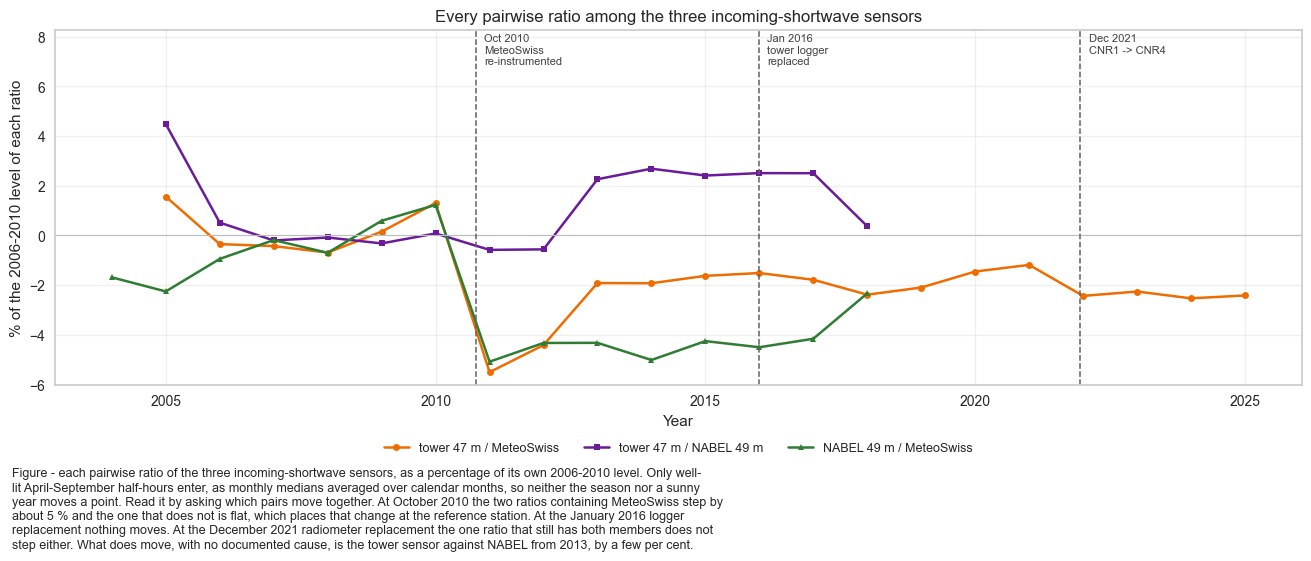

In [36]:

# The three ratios drawn together, with the three dates this section is about marked on them. The
# tables above are two rows of this figure; the figure shows which changes are steps, which are
# drifts, and which pairs move together - none of which two window means can convey.
# Drawn after the fieldbook and reference-file evidence above has fixed the dates, so every marked
# date comes from a file rather than from a number written here.
fig, ax = plt.subplots(figsize=(13, 5.5), dpi=100, layout="constrained")
_rel = 100 * (ratio_table / ratio_table.loc[2006:2010].mean() - 1)
for (_label, _colour, _marker) in [('tower 47 m / MeteoSwiss', '#EF6C00', 'o'),
                                   ('tower 47 m / NABEL 49 m', '#6A1B9A', 's'),
                                   ('NABEL 49 m / MeteoSwiss', '#2E7D32', '^')]:
    ax.plot(_rel.index, _rel[_label], color=_colour, lw=1.8, marker=_marker, ms=5, label=_label)
ax.axhline(0, color='#BDBDBD', lw=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("% of the 2006-2010 level of each ratio")
ax.set_title("Every pairwise ratio among the three incoming-shortwave sensors")
ax.grid(alpha=0.3)

# Headroom at the top so the event labels sit above the lines rather than across the legend.
_lo, _hi = ax.get_ylim()
ax.set_ylim(_lo, _hi + 0.30 * (_hi - _lo))
_top = ax.get_ylim()[1]
for _x, _text in [(_diffuse_start.year + 0.75, 'Oct 2010\nMeteoSwiss\nre-instrumented'),
                  (BREAK_YEAR, f'Jan {BREAK_YEAR}\ntower logger\nreplaced'),
                  (CNR4_YEAR - 0.05, f'Dec {CNR4_YEAR - 1}\nCNR1 -> CNR4')]:
    ax.axvline(_x, color='#616161', lw=1.1, ls='--')
    ax.text(_x + 0.15, _top - 0.15, _text, fontsize=8, color='#424242', va='top')
ax.legend(fontsize=9, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.13),
          frameon=False)
figcap(fig, "each pairwise ratio of the three incoming-shortwave sensors, as a percentage of its "
            "own 2006-2010 level. Only well-lit April-September half-hours enter, as monthly "
            "medians averaged over calendar months, so neither the season nor a sunny year moves "
            "a point. Read it by asking which pairs move together. At October 2010 the two ratios "
            "containing MeteoSwiss step by about 5 % and the one that does not is flat, which "
            "places that change at the reference station. At the January 2016 logger replacement "
            "nothing moves. At the December 2021 radiometer replacement the one ratio that still "
            "has both members does not step either. What does move, with no documented cause, is "
            "the tower sensor against NABEL from 2013, by a few per cent.")


C:\Users\nopan\AppData\Local\Temp\ipykernel_5948\2621636459.py:27: RuntimeWarning: divide by zero encountered in divide
  axs[1].plot(_grid, 100 * ((_slope * _grid + _icpt) / _grid - 1), color=_colour, lw=2.2,


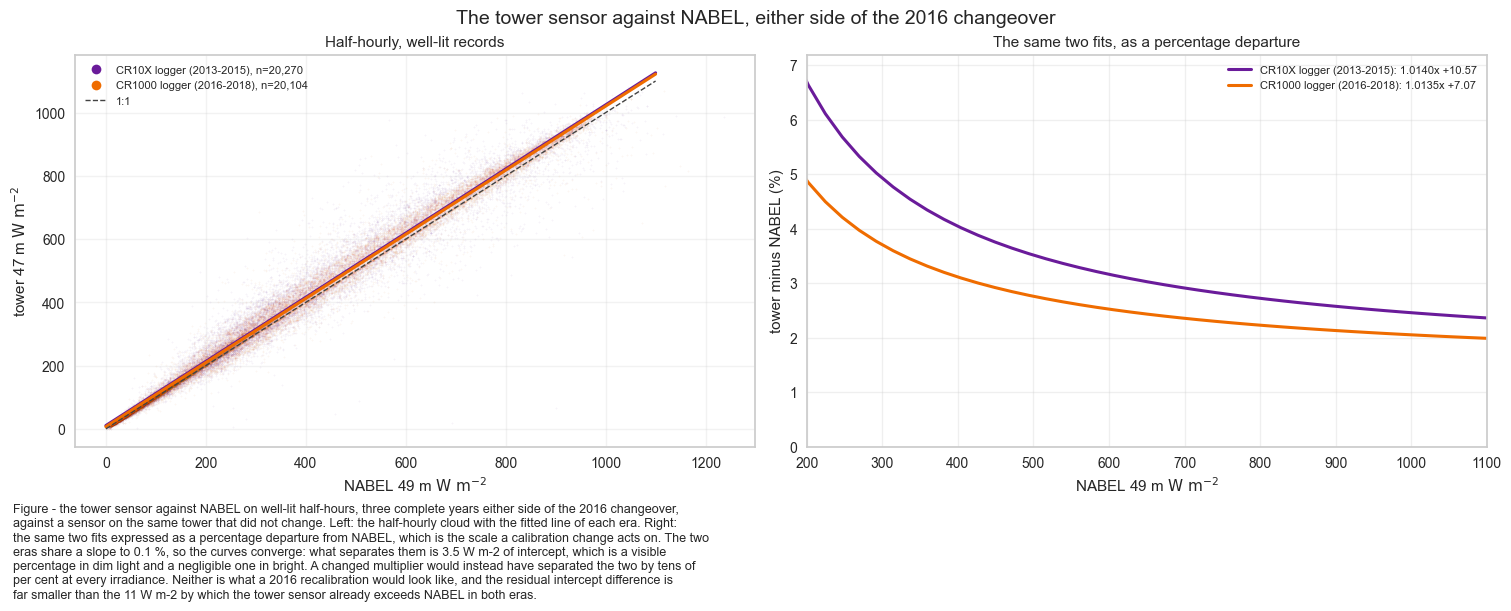

In [37]:
# The 2016 changeover drawn as the relationship it would have moved. If the acquisition change had
# rescaled the series, the two eras would fall on visibly different lines against a sensor that
# did not change; a step in the intercept would show as a vertical offset and a gain change as a
# different slope.
_lit_era = (POTRAD > WELL_LIT)
fig, axs = plt.subplots(ncols=2, figsize=(15, 6), dpi=100, layout='constrained')
fig.suptitle(f"The tower sensor against NABEL, either side of the {BREAK_YEAR} changeover",
             fontsize=14)

_eras = [(f'CR10X logger (2013-2015)', (2013, 2015), '#6A1B9A'),
         (f'CR1000 logger ({BREAK_YEAR}-2018)', (BREAK_YEAR, 2018), '#EF6C00')]
_fits = {}
for _label, (_y0, _y1), _colour in _eras:
    _sel = _lit_era & (swin_2004_2025.index.year >= _y0) & (swin_2004_2025.index.year <= _y1)
    _j = swin_2004_2025.loc[_sel, ['SW_IN_T1_47_1', 'SW_IN_NABEL_T1_49_1']].dropna()
    _slope, _icpt = np.polyfit(_j['SW_IN_NABEL_T1_49_1'].to_numpy(),
                               _j['SW_IN_T1_47_1'].to_numpy(), 1)
    _fits[_label] = (_slope, _icpt, len(_j))
    axs[0].scatter(_j['SW_IN_NABEL_T1_49_1'], _j['SW_IN_T1_47_1'], s=1, alpha=0.04,
                   color=_colour, rasterized=True)
    axs[0].plot([], [], 'o', color=_colour, label=f"{_label}, n={len(_j):,}")

_grid = np.linspace(0, 1100, 50)
for _label, (_y0, _y1), _colour in _eras:
    _slope, _icpt, _n = _fits[_label]
    axs[0].plot(_grid, _slope * _grid + _icpt, color=_colour, lw=2.2)
    axs[1].plot(_grid, 100 * ((_slope * _grid + _icpt) / _grid - 1), color=_colour, lw=2.2,
                label=f"{_label}: {_slope:.4f}x {_icpt:+.2f}")
axs[0].plot([0, 1100], [0, 1100], color='#424242', lw=1.0, ls='--', label='1:1')
axs[0].set_xlabel(r'NABEL 49 m $\mathrm{W\ m^{-2}}$')
axs[0].set_ylabel(r'tower 47 m $\mathrm{W\ m^{-2}}$')
axs[0].set_title('Half-hourly, well-lit records', fontsize=11)
axs[0].legend(fontsize=8, loc='upper left')
axs[0].grid(alpha=0.25)

axs[1].axhline(0, color='#BDBDBD', lw=0.8)
# The percentage departure diverges as the denominator goes to zero, so the panel is limited
# to the range where the two eras are actually being compared.
axs[1].set_xlim(200, 1100)
_dep_vals = [100 * ((_fits[_l][0] * _x + _fits[_l][1]) / _x - 1)
             for _l, _, _ in _eras for _x in (200, 1100)]
axs[1].set_ylim(min(0, min(_dep_vals) - 0.5), max(_dep_vals) + 0.5)
axs[1].set_xlabel(r'NABEL 49 m $\mathrm{W\ m^{-2}}$')
axs[1].set_ylabel('tower minus NABEL (%)')
axs[1].set_title('The same two fits, as a percentage departure', fontsize=11)
axs[1].legend(fontsize=8)
axs[1].grid(alpha=0.3)

_slopes = [_fits[_l][0] for _l, _, _ in _eras]
_icpts = [_fits[_l][1] for _l, _, _ in _eras]
figcap(fig, f"the tower sensor against NABEL on well-lit half-hours, three complete years either "
            f"side of the {BREAK_YEAR} changeover, against a sensor on the same tower that did "
            f"not change. Left: the half-hourly cloud with the fitted line of each era. Right: "
            f"the same two fits expressed as a percentage departure from NABEL, which is the "
            f"scale a calibration change acts on. The two eras share a slope to "
            f"{100 * abs(_slopes[1] - _slopes[0]) / _slopes[0]:.1f} %, so the curves "
            f"converge: what separates them is {abs(_icpts[1] - _icpts[0]):.1f} W m-2 of "
            f"intercept, which is a visible percentage in dim light and a negligible one in "
            f"bright. A changed multiplier would instead have separated the two by tens of "
            f"per cent at every irradiance. Neither is what a 2016 recalibration would look "
            f"like, and the residual intercept difference is far smaller than the "
            f"{abs(_icpts[0]):.0f} W m-2 by which the tower sensor already exceeds NABEL in "
            f"both eras.")

### 7️⃣ What is left unexplained

The same scan shows the tower sensor departing from **both** references from 2013, by a few per cent,
and returning towards them later. It is not a step at a date, no maintenance record covers it, and
the fieldbook records no calibration of this CNR1 between its installation in 2005 and its removal
in 2021.

A departure of this size is inside the field uncertainty of a pyranometer of this class over that interval, and
nothing in the evidence separates a drift of the tower sensor from a drift of NABEL's. It is
therefore **recorded, not corrected**: correcting a 2 % departure that cannot be attributed to a
particular instrument would replace a measurement with a guess. The full four-sensor treatment,
which adds the co-located PAR sensor as a third witness, is in
`RADIATION_SENSOR_CONTINUITY.ipynb`.


In [38]:

# What the same scan leaves unexplained, stated rather than left to be found. The tower sensor
# departs from both references over 2013-2015 and returns; nothing in the fieldbook covers it.
_dep = pd.DataFrame({_l: RATIOS[_l] for _l in RATIOS})
_dep = 100 * (_dep / _dep.loc[2006:2010].mean() - 1)
DEPARTURE_YEARS = [2013, 2014, 2015, 2016, 2017]
tabcap("the tower sensor against both references over the years of the departure, as a percentage "
       "of the 2006-2010 level of each ratio")
display(_dep.loc[DEPARTURE_YEARS].round(2))

_worst = _dep.loc[DEPARTURE_YEARS, 'tower 47 m / NABEL 49 m'].abs().max()
print(f"\nlargest departure of the tower sensor from NABEL over {DEPARTURE_YEARS[0]}-"
      f"{DEPARTURE_YEARS[-1]}: {_worst:.2f} %")
print("It is not corrected here: it is within the field uncertainty of a pyranometer of this "
      "class, it develops rather than steps, and no maintenance record covers it. It is recorded "
      "as a limitation of the product and examined in RADIATION_SENSOR_CONTINUITY.ipynb.")
assert _worst < 5.0, (
    "the unexplained departure has grown past the field uncertainty of the instrument - it can no "
    "longer be left uncorrected on the grounds given here")


Table - the tower sensor against both references over the years of the departure, as a percentage of
the 2006-2010 level of each ratio



,tower 47 m / MeteoSwiss,tower 47 m / NABEL 49 m,NABEL 49 m / MeteoSwiss
year,,,
2013,-1.91,2.27,-4.32
2014,-1.92,2.69,-5.01
2015,-1.62,2.41,-4.25
2016,-1.51,2.51,-4.50
2017,-1.78,2.51,-4.16



largest departure of the tower sensor from NABEL over 2013-2017: 2.69 %
It is not corrected here: it is within the field uncertainty of a pyranometer of this class, it develops rather than steps, and no maintenance record covers it. It is recorded as a limitation of the product and examined in RADIATION_SENSOR_CONTINUITY.ipynb.


#### What this section settles

`SW_IN_T1_47_1` is **homogeneous across the January 2016 acquisition change** — the sensor, its
calibration constant and the level of the data are all unchanged — and it is homogeneous across
the December 2021 radiometer replacement as well. No correction is applied for either, and no
`_HOMOGENIZED` column is exported, because there is nothing to homogenise.

The series carries one known inhomogeneity of its own, the unattributed 2 % departure from 2013,
and one property of its inputs that a reader has to know about: the MeteoSwiss driver changed
level in October 2010. Both are recorded on the `SW_IN` page of the documentation.

The assertions above exist so that this stops being a matter of memory. If a re-run of this
notebook ever finds a step at either changeover, it fails here rather than exporting a product
that quietly reports an instrument change as radiation.


## 🟪 Prepare dataframes

Split into the two periods that are gap-filled separately: **2004-2018**, where NABEL and Lägern
are both available as drivers, and **2019-2025**, where NABEL has stopped and Lägern is the only
one. `SW_IN_NABEL_T1_49_1` is dropped from the second frame because it is empty there.

In [39]:
swin_2004_2018 = swin_2004_2025.loc[swin_2004_2025.index.year <= 2018].copy()
swin_2004_2018

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1,SW_IN_LAE_MS
TIMESTAMP_MIDDLE,,,
2004-01-01 00:15:00,NaN,0.0,NaN
2004-01-01 00:45:00,NaN,0.0,NaN
2004-01-01 01:15:00,NaN,0.0,NaN
2004-01-01 01:45:00,NaN,0.0,NaN
2004-01-01 02:15:00,NaN,0.0,NaN
...,...,...,...
2018-12-31 21:45:00,0.0,0.0,2.000000
2018-12-31 22:15:00,0.0,0.0,2.000000
2018-12-31 22:45:00,0.0,0.0,2.000000


In [40]:
swin_2019_2025 = swin_2004_2025.loc[swin_2004_2025.index.year >= 2019].copy()
swin_2019_2025 = swin_2019_2025.drop('SW_IN_NABEL_T1_49_1', axis=1)
swin_2019_2025

,SW_IN_T1_47_1,SW_IN_LAE_MS
TIMESTAMP_MIDDLE,,
2019-01-01 00:15:00,0.0,2.333333
2019-01-01 00:45:00,0.0,2.000000
2019-01-01 01:15:00,0.0,2.000000
2019-01-01 01:45:00,0.0,2.000000
2019-01-01 02:15:00,0.0,2.000000
...,...,...
2025-12-31 21:45:00,0.0,2.333333
2025-12-31 22:15:00,0.0,2.000000
2025-12-31 22:45:00,0.0,1.666667


***

## 🟥 Gap-filling ETH (2004-2018)
- Drivers: NABEL (49 m, same tower) and MeteoSwiss Lägern, both as measured

`SWINGapFillerXGBoost` computes `SW_IN_POT` from the site coordinates, uses it to split day from
night, sets nighttime gaps to zero and fills daytime gaps with XGBoost. Negatives are clipped
internally, and `correct_nighttime_offset=True` finds nothing left to remove because the offset
was taken out above.

**Both drivers enter as measured**, so the target never partly predicts itself. NABEL is gappy;
Lägern covers those gaps at 99.6% presence. Where *both* are missing the gap-filler falls back to
a timestamp-only model and marks the record **flag 2** — that flag is the count of half-hours
where this happened.

**Short daytime gaps** (up to 1 h) can be interpolated from the neighbours instead of modelled,
which is only the better option when no second radiation sensor exists. Lägern is present in both
runs, so `interpolate_short_gaps='auto'` resolves to *off* in both.

| Run | Drivers (`context_df`) |
|---|---|
| ETH 2004-2018 | NABEL (measured) + Lägern |
| ETH 2019-2025 | Lägern |

### Run gap-filling

`SW_IN_POT` and the timestamp features are added by the gap-filler itself; `context_df` supplies
the two independent radiation measurements.

NABEL sits at 49 m on the same tower and is the closer of the two, but stops in 2018 and has gaps
of its own. Lägern is 2.5 km away and continuous. Between them the model almost always sees a real
sky state rather than only the time of day.

In [41]:
%%time

TARGET = "SW_IN_T1_47_1"

gf_eth_2004_2018 = dv.gapfilling.SWINGapFillerXGBoost(
    series=swin_2004_2018[TARGET],
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    # Both drivers as measured. NABEL is gappy; Lägern (99.6% present) covers those gaps,
    # so neither the tower nor a model-filled series is used to predict the tower.
    context_df=swin_2004_2018[['SW_IN_NABEL_T1_49_1', REFCOL]],
    correct_nighttime_offset=True,
    # interpolate_short_gaps left at 'auto': drivers are given, so interpolation stays OFF
    reduce_features=True,
    verbose=1,
    # XGBoost hyperparameters are left at the class defaults (n_estimators, max_depth,
    # early_stopping_rounds, random_state). They are tuned for SW_IN and keep a run
    # reproducible; only n_jobs is set here.
    n_jobs=-1,
)
gf_eth_2004_2018.run()

──────────────────────────────── SW_IN Gap-Filling (SW_IN_T1_47_1) ─────────────────────────────────

> running remove_nighttime_zero_offset ...

Output()

> Step 1: Correcting nighttime sensor offset (1.3s)

Output()

...

> Step 6: Reducing features (SHAP vs random benchmark) and retraining (1.0s)

Output()

> Step 7: Filling daytime gaps (SHAP importances over full record) (4.6s)

v Done in 9.7s - 33155 records filled (33155 gaps total)

CPU times: total: 2min 11s
Wall time: 9.75 s


### Report

In [42]:
gf_eth_2004_2018.report()

───────────────────────────── SW_IN Gap-Filling Report: SW_IN_T1_47_1 ──────────────────────────────

Algorithm: physics-aware partitioning + XGBoost
    Nighttime gaps  -> set to 0 W m-2 (no incoming solar radiation)
    Daytime gaps    -> XGBoost trained on daytime observations
    Day/night split -> SW_IN_POT (potential radiation) vs threshold

──────────────────────────────────────────── Parameters ────────────────────────────────────────────

Site latitude              47.478333
  Site longitude             8.364389
  UTC offset                 1
  Nighttime threshold        0.001 W m-2  (SW_IN_POT < threshold -> night)
  Correct nighttime offset   True
  Reduce features (SHAP)     True
  context drivers            ['SW_IN_NABEL_T1_49_1', 'SW_IN_LAE_MS']

─────────────────────────────────────── Feature engineering ────────────────────────────────────────

...

MSE      868.2587

RMSE     29.4662

MAPE     64473181249663.6094

MAXE     729.3863

R2       0.9879

### Results: scores and feature importances

In [43]:
r = gf_eth_2004_2018.results
tabcap("held-out scores of the SW_IN_T1_47_1 (2004-2018) daytime model. These are computed on records kept out of training, so they describe the fills rather than the fit")
display(pd.Series(r.scores_traintest))
tabcap("how many records of the SW_IN_T1_47_1 (2004-2018) period each provenance code accounts for")
display(r.flag.value_counts().sort_index().rename(index=FLAG_LEGEND))

Table - held-out scores of the SW_IN_T1_47_1 (2004-2018) daytime model. These are computed on
records kept out of training, so they describe the fills rather than the fit



mae      1.612012e+01
medae    6.344359e+00
mse      1.082076e+03
rmse     3.289493e+01
mape     5.887277e+13
maxe     6.607116e+02
r2       9.847740e-01
dtype: float64

Table - how many records of the SW_IN_T1_47_1 (2004-2018) period each provenance code accounts for



flag
0 = observed                                                                           229837
1 = daytime gap, filled by the XGBoost model                                            17011
2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)       697
3 = nighttime gap, set to zero by physics                                               15447
Name: count, dtype: int64

Table - driver importance for the SW_IN_T1_47_1 (2004-2018) daytime model, as the gap-filler reports
it



,SHAP_IMPORTANCE,SHAP_SD
SW_IN_NABEL_T1_49_1,203.099503,132.247116
SW_IN_LAE_MS,11.639704,8.465756
.SW_IN_NABEL_T1_49_1_ROLLMEDIAN4,7.505960,6.374772
.SW_IN_NABEL_T1_49_1_MEAN4,5.144228,3.136867
.SW_IN_LAE_MS_MEAN4,3.874487,6.337811
.YEARMONTH,2.448386,2.500463
.SW_IN_LAE_MS_ROLLMEDIAN4,2.331740,3.361353
.YEARDOY,1.980273,1.815813
.SW_IN_NABEL_T1_49_1_EMA6,1.838733,2.263361
.HOUR_SIN,1.823360,2.058879


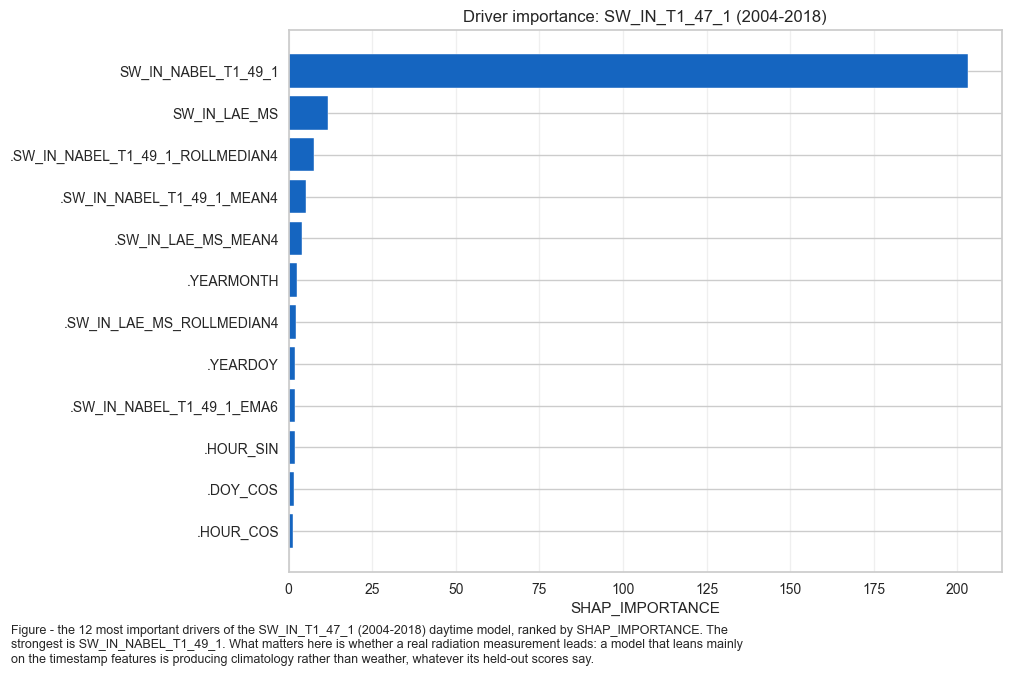

In [44]:
tabcap("driver importance for the SW_IN_T1_47_1 (2004-2018) daytime model, as the gap-filler reports it")
display(r.feature_importances)
plot_feature_importances(r, label="SW_IN_T1_47_1 (2004-2018)");

### Add gap-filled series to dataframe

In [45]:
gapfilled_eth_2004_2018 = gf_eth_2004_2018.results.gapfilled.rename(f"{TARGET}_gfXG")
swin_2004_2018[gapfilled_eth_2004_2018.name] = gapfilled_eth_2004_2018

# This flag IS exported (see the export section). Held as a standalone series rather than a
# dataframe column so the plotting cells below keep showing radiation only.
flag_eth_2004_2018 = gf_eth_2004_2018.results.flag.rename(f"FLAG_{TARGET}_ISFILLED")
tabcap("the exported provenance flag for the SW_IN_T1_47_1 (2004-2018) period, by code")
display(flag_eth_2004_2018.value_counts().sort_index().rename(index=FLAG_LEGEND))

tabcap("the measured and the gap-filled column of the 2004-2018 period. The gap-filled column has no missing records by construction; comparing the two means shows what the fills contribute")
swin_2004_2018[[TARGET, gapfilled_eth_2004_2018.name]].describe()

Table - the exported provenance flag for the SW_IN_T1_47_1 (2004-2018) period, by code



FLAG_SW_IN_T1_47_1_ISFILLED
0 = observed                                                                           229837
1 = daytime gap, filled by the XGBoost model                                            17011
2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)       697
3 = nighttime gap, set to zero by physics                                               15447
Name: count, dtype: int64

Table - the measured and the gap-filled column of the 2004-2018 period. The gap-filled column has no
missing records by construction; comparing the two means shows what the fills contribute



,SW_IN_T1_47_1,SW_IN_T1_47_1_gfXG
count,229837.000000,262992.000000
mean,142.603195,144.261782
std,236.721217,238.046170
min,0.000000,0.000000
25%,0.000000,0.000000
50%,3.657932,4.197031
75%,190.252314,195.239186
max,1111.028655,1111.028655


#### Plot: measured, gap-filled and the fills on their own

The bottom panel shows only the gap-filled values. Anything that looks wrong there — fills at an
implausible level, or a long block of fills — is worth following up, because it is invisible in
the combined series.

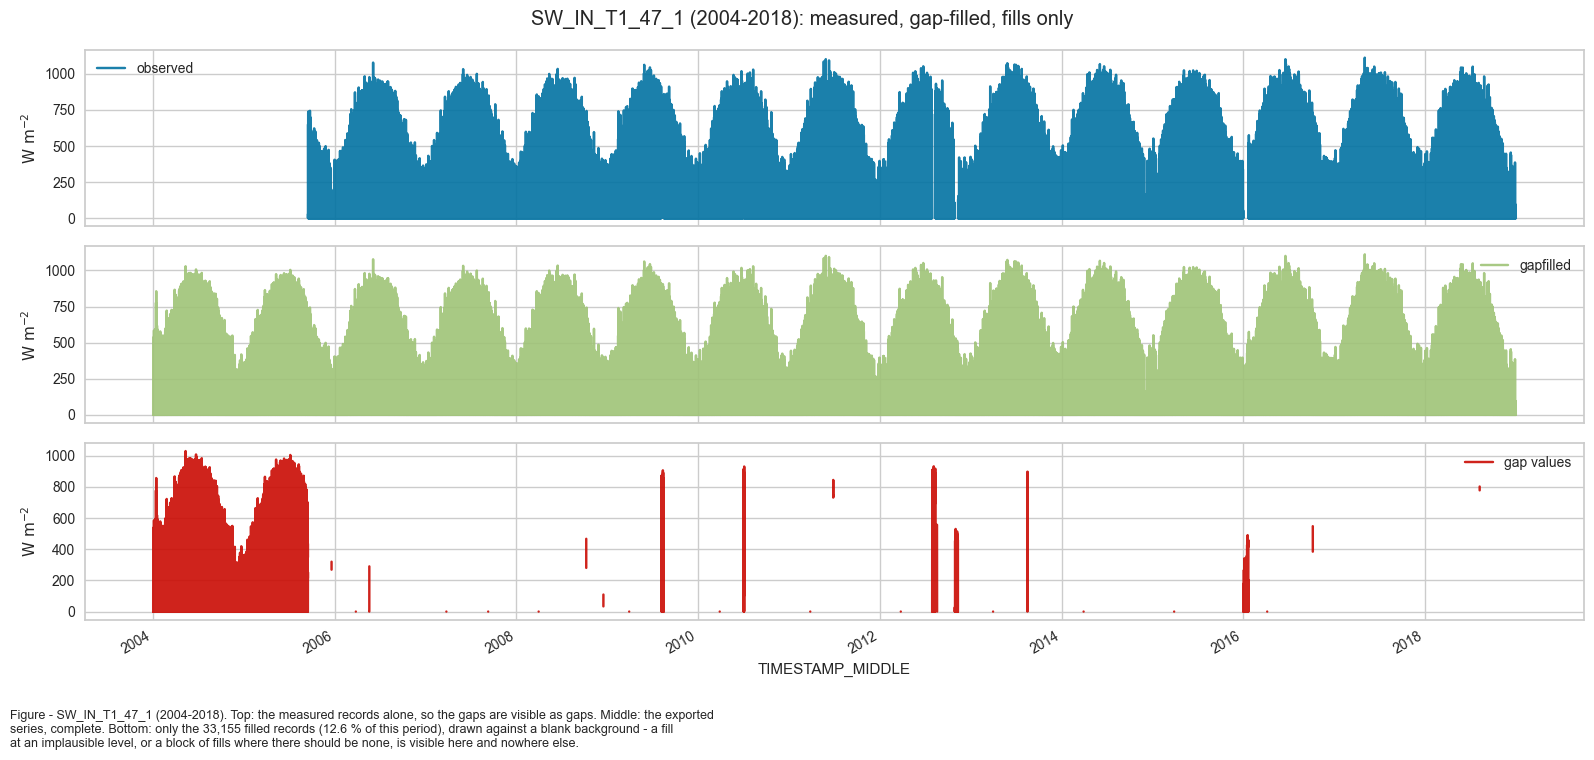

In [46]:
plot_gapfill_panels(gf_eth_2004_2018.results, label="SW_IN_T1_47_1 (2004-2018)");

#### Plot: predicted vs measured on held-out data

The model never saw these records during training, so this is the view that shows whether the
daytime model is actually any good. A tilt in the residual panel means bias; a widening cone means
the error grows with the value, which for radiation is expected.

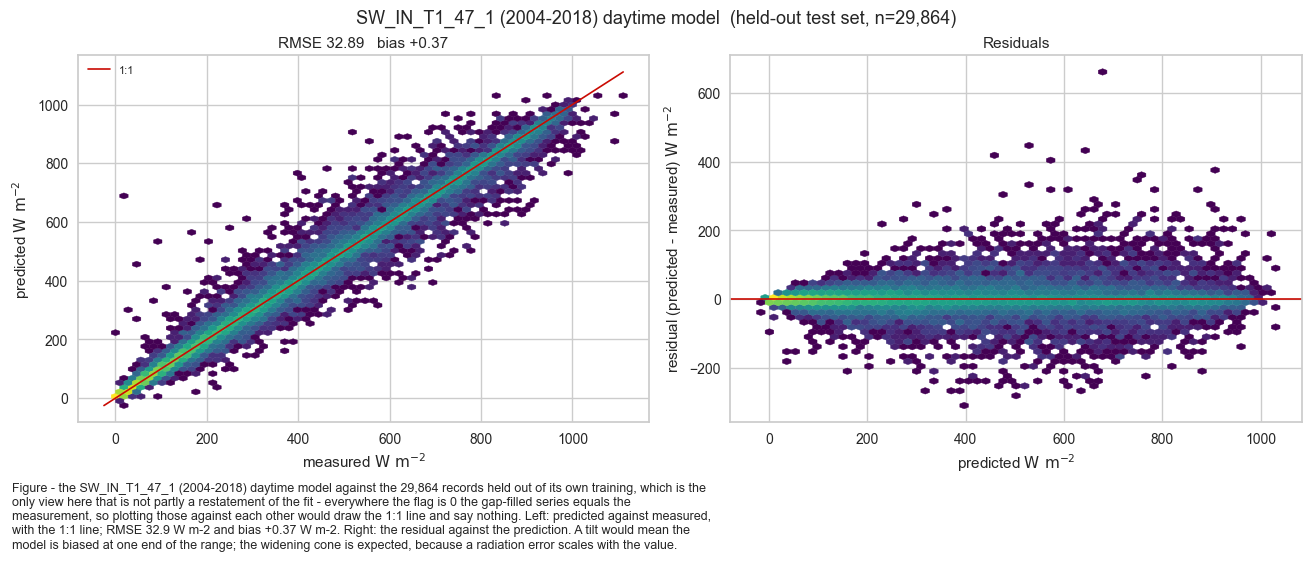

In [47]:
plot_pred_vs_measured(gf_eth_2004_2018.daytime_model_, label="SW_IN_T1_47_1 (2004-2018)");

### Dataframe

In [48]:
tabcap("the 2004-2018 frame with its gap-filled column added")
display(swin_2004_2018)
swin_2004_2018.describe()

Table - the 2004-2018 frame with its gap-filled column added



,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1,SW_IN_LAE_MS,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,,
2004-01-01 00:15:00,NaN,0.0,NaN,0.0
2004-01-01 00:45:00,NaN,0.0,NaN,0.0
2004-01-01 01:15:00,NaN,0.0,NaN,0.0
2004-01-01 01:45:00,NaN,0.0,NaN,0.0
2004-01-01 02:15:00,NaN,0.0,NaN,0.0
...,...,...,...,...
2018-12-31 21:45:00,0.0,0.0,2.000000,0.0
2018-12-31 22:15:00,0.0,0.0,2.000000,0.0
2018-12-31 22:45:00,0.0,0.0,2.000000,0.0


,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1,SW_IN_LAE_MS,SW_IN_T1_47_1_gfXG
count,229837.000000,262774.000000,261392.000000,262992.000000
mean,142.603195,140.035108,139.777236,144.261782
std,236.721217,233.702051,229.285462,238.046170
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000,0.000000
50%,3.657932,2.495635,5.333333,4.197031
75%,190.252314,186.456335,186.000000,195.239186
max,1111.028655,1236.721293,1155.333333,1111.028655


***

### Plots

#### Heatmap

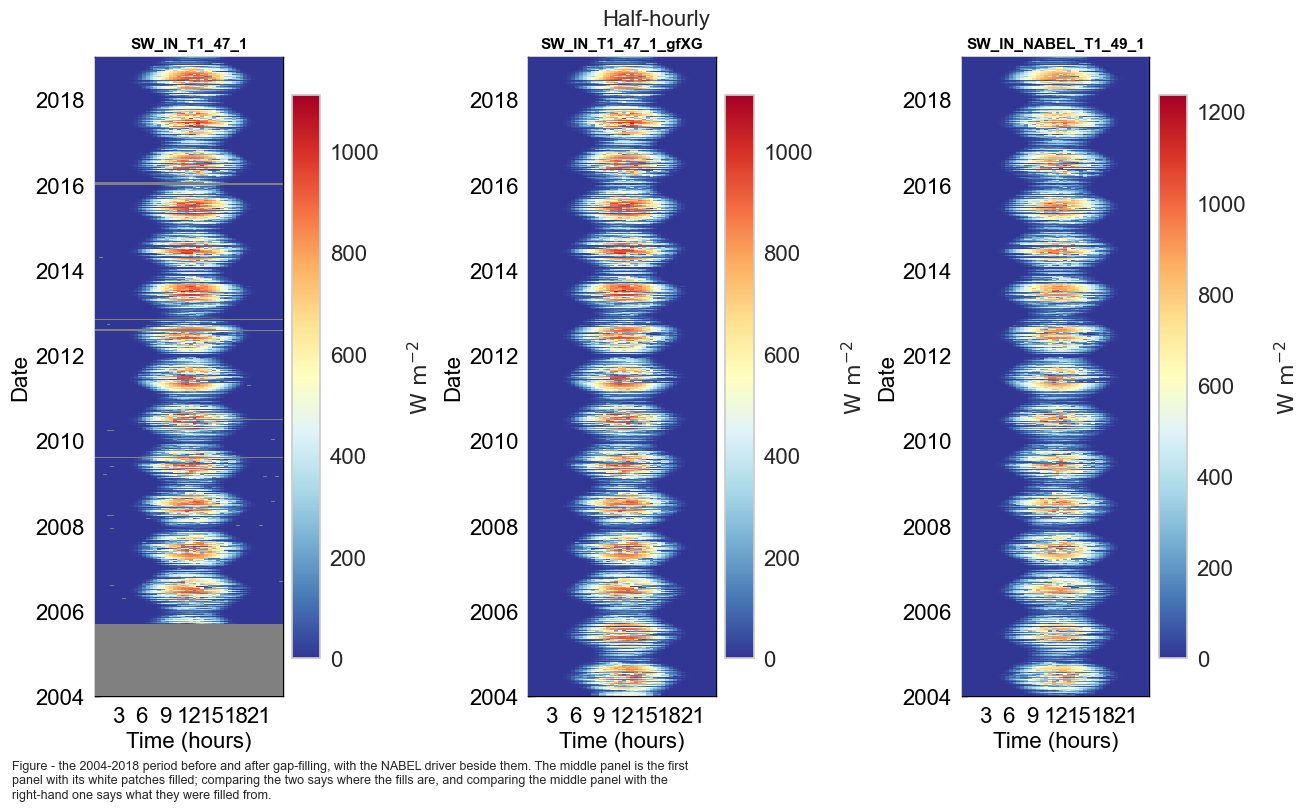

In [49]:
fig, axs = plt.subplots(ncols=3, figsize=(13, 8), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
for _ax, _col in zip(axs, ['SW_IN_T1_47_1', 'SW_IN_T1_47_1_gfXG', 'SW_IN_NABEL_T1_49_1']):
    dv.plotting.HeatmapDateTime(series=swin_2004_2018[_col]).plot(
        ax=_ax, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title=_col, title_fontsize=11))
figcap(fig, "the 2004-2018 period before and after gap-filling, with the NABEL driver beside "
            "them. The middle panel is the first panel with its white patches filled; comparing "
            "the two says where the fills are, and comparing the middle panel with the right-hand "
            "one says what they were filled from.")

#### Time series plot

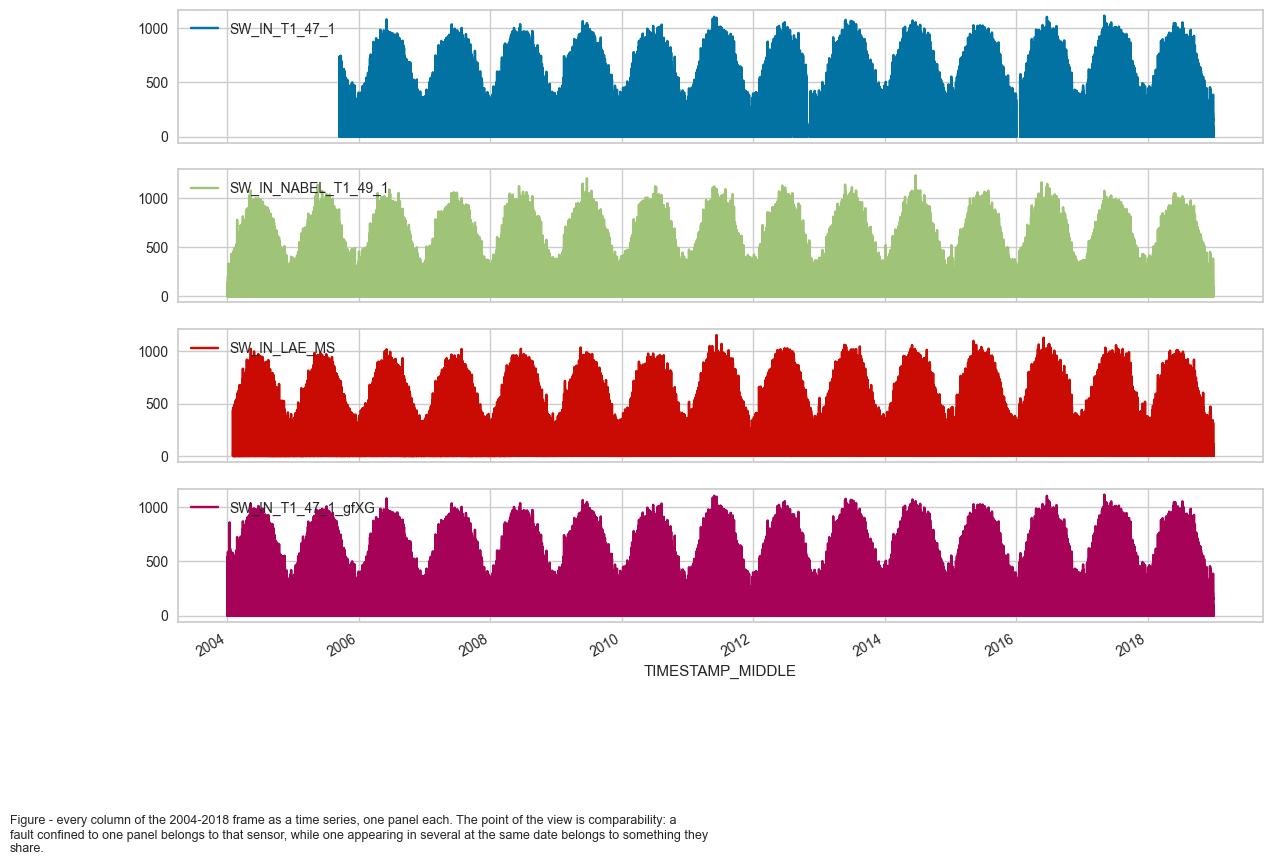

In [50]:
_axs = swin_2004_2018.plot(subplots=True, x_compat=True, figsize=(14, 9))
figcap(_axs[0].get_figure(), "every column of the 2004-2018 frame as a time series, one "
                             "panel each. The point of the view is comparability: a fault "
                             "confined to one panel belongs to that sensor, while one "
                             "appearing in several at the same date belongs to something "
                             "they share.");

***

## 🟧 Gap-filling ETH (2019-2025)
- From mst (2019-2021) and diive meteoscreening (2022-2025)
- NABEL has stopped. **MeteoSwiss Lägern is the only radiation driver.**

::: {.callout-note title="How to read flag 1 in this period"}
Lägern is present for 100% of the filled records here and tracks the tower closely on daytime
half-hours, so these fills follow the actual sky state rather than a typical value for the time of
year.

They are still *estimates from a nearby sensor*: Lägern sits 2.5 km away on the ridge at 845 m,
with its own exposure and a small systematic offset the model has to learn. With one driver
instead of two, flag `1` records here are less certain than their 2004-2018 counterparts.
:::

### Run gap-filling

In [51]:
%%time

TARGET = "SW_IN_T1_47_1"

gf_eth_2019_2025 = dv.gapfilling.SWINGapFillerXGBoost(
    series=swin_2019_2025[TARGET],
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    context_df=swin_2019_2025[[REFCOL]],  # Lägern: the only radiation driver in this period
    correct_nighttime_offset=True,
    # interpolate_short_gaps left at 'auto'. A driver is now given, so this resolves to OFF
    # and no longer overwrites the model fills, which are now informed by a real sky state.
    reduce_features=True,
    verbose=1,
    # XGBoost hyperparameters are left at the class defaults (n_estimators, max_depth,
    # early_stopping_rounds, random_state). They are tuned for SW_IN and keep a run
    # reproducible; only n_jobs is set here.
    n_jobs=-1,
)
gf_eth_2019_2025.run()

──────────────────────────────── SW_IN Gap-Filling (SW_IN_T1_47_1) ─────────────────────────────────

> running remove_nighttime_zero_offset ...

Output()

> Step 1: Correcting nighttime sensor offset (0.6s)

Output()

...

> Step 6: Reducing features (SHAP vs random benchmark) and retraining (1.2s)

Output()

> Step 7: Filling daytime gaps (SHAP importances over full record) (0.4s)

v Done in 4.1s - 847 records filled (847 gaps total)

CPU times: total: 49.9 s
Wall time: 4.07 s


### Report

In [52]:
gf_eth_2019_2025.report()

───────────────────────────── SW_IN Gap-Filling Report: SW_IN_T1_47_1 ──────────────────────────────

Algorithm: physics-aware partitioning + XGBoost
    Nighttime gaps  -> set to 0 W m-2 (no incoming solar radiation)
    Daytime gaps    -> XGBoost trained on daytime observations
    Day/night split -> SW_IN_POT (potential radiation) vs threshold

──────────────────────────────────────────── Parameters ────────────────────────────────────────────

Site latitude              47.478333
  Site longitude             8.364389
  UTC offset                 1
  Nighttime threshold        0.001 W m-2  (SW_IN_POT < threshold -> night)
  Correct nighttime offset   True
  Reduce features (SHAP)     True
  context drivers            ['SW_IN_LAE_MS']

─────────────────────────────────────── Feature engineering ────────────────────────────────────────

...

MSE      2176.4933

RMSE     46.6529

MAPE     144680013012298.0625

MAXE     640.7285

R2       0.9712

### Results: scores and feature importances

In [53]:
r = gf_eth_2019_2025.results
tabcap("held-out scores of the SW_IN_T1_47_1 (2019-2025) daytime model. These are computed on records kept out of training, so they describe the fills rather than the fit")
display(pd.Series(r.scores_traintest))
tabcap("how many records of the SW_IN_T1_47_1 (2019-2025) period each provenance code accounts for")
display(r.flag.value_counts().sort_index().rename(index=FLAG_LEGEND))

Table - held-out scores of the SW_IN_T1_47_1 (2019-2025) daytime model. These are computed on
records kept out of training, so they describe the fills rather than the fit



mae      2.912316e+01
medae    1.226814e+01
mse      3.108535e+03
rmse     5.575424e+01
mape     1.305378e+14
maxe     6.407285e+02
r2       9.587625e-01
dtype: float64

Table - how many records of the SW_IN_T1_47_1 (2019-2025) period each provenance code accounts for



flag
0 = observed                                    121889
1 = daytime gap, filled by the XGBoost model       400
3 = nighttime gap, set to zero by physics          447
Name: count, dtype: int64

Table - driver importance for the SW_IN_T1_47_1 (2019-2025) daytime model, as the gap-filler reports
it



,SHAP_IMPORTANCE,SHAP_SD
SW_IN_LAE_MS,197.179459,123.591957
SW_IN_POT,18.260439,11.492335
.SW_IN_LAE_MS_MEAN4,10.088753,6.276229
.SW_IN_LAE_MS_ROLLMEDIAN4,8.768586,8.276722
.SW_IN_LAE_MS_MEAN8,4.537827,2.573359
.SW_IN_LAE_MS_EMA6,4.373403,3.475349
.YEARDOY,3.911958,3.374832
.HOUR_SIN,3.801167,3.218277
.SW_IN_LAE_MS_ROLLMEDIAN8,3.769056,3.152824
.SW_IN_LAE_MS_MEAN48,3.508657,3.683447


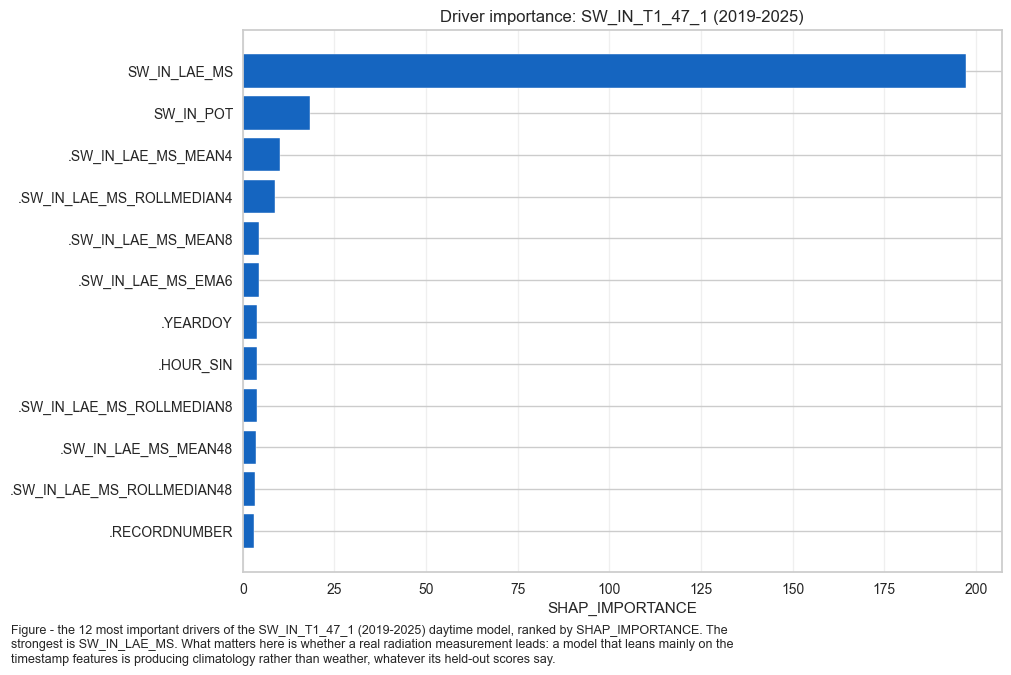

In [54]:
tabcap("driver importance for the SW_IN_T1_47_1 (2019-2025) daytime model, as the gap-filler reports it")
display(r.feature_importances)
plot_feature_importances(r, label="SW_IN_T1_47_1 (2019-2025)");

### Add gap-filled series to dataframe

In [55]:
gapfilled_eth_2019_2025 = gf_eth_2019_2025.results.gapfilled.rename(f"{TARGET}_gfXG")
swin_2019_2025[gapfilled_eth_2019_2025.name] = gapfilled_eth_2019_2025

# This flag IS exported (see the export section).
flag_eth_2019_2025 = gf_eth_2019_2025.results.flag.rename(f"FLAG_{TARGET}_ISFILLED")
tabcap("the exported provenance flag for the SW_IN_T1_47_1 (2019-2025) period, by code")
display(flag_eth_2019_2025.value_counts().sort_index().rename(index=FLAG_LEGEND))

tabcap("the measured and the gap-filled column of the 2019-2025 period")
swin_2019_2025[[TARGET, gapfilled_eth_2019_2025.name]].describe()

Table - the exported provenance flag for the SW_IN_T1_47_1 (2019-2025) period, by code



FLAG_SW_IN_T1_47_1_ISFILLED
0 = observed                                    121889
1 = daytime gap, filled by the XGBoost model       400
3 = nighttime gap, set to zero by physics          447
Name: count, dtype: int64

Table - the measured and the gap-filled column of the 2019-2025 period



,SW_IN_T1_47_1,SW_IN_T1_47_1_gfXG
count,121889.000000,122736.000000
mean,149.817717,149.352257
std,245.046332,244.630334
min,0.000000,0.000000
25%,0.000000,0.000000
50%,3.723554,3.638556
75%,205.228608,204.050755
max,1118.658439,1118.658439


#### Plot: measured, gap-filled and the fills on their own

The bottom panel shows only the gap-filled values. Anything that looks wrong there — fills at an
implausible level, or a long block of fills — is worth following up, because it is invisible in
the combined series.

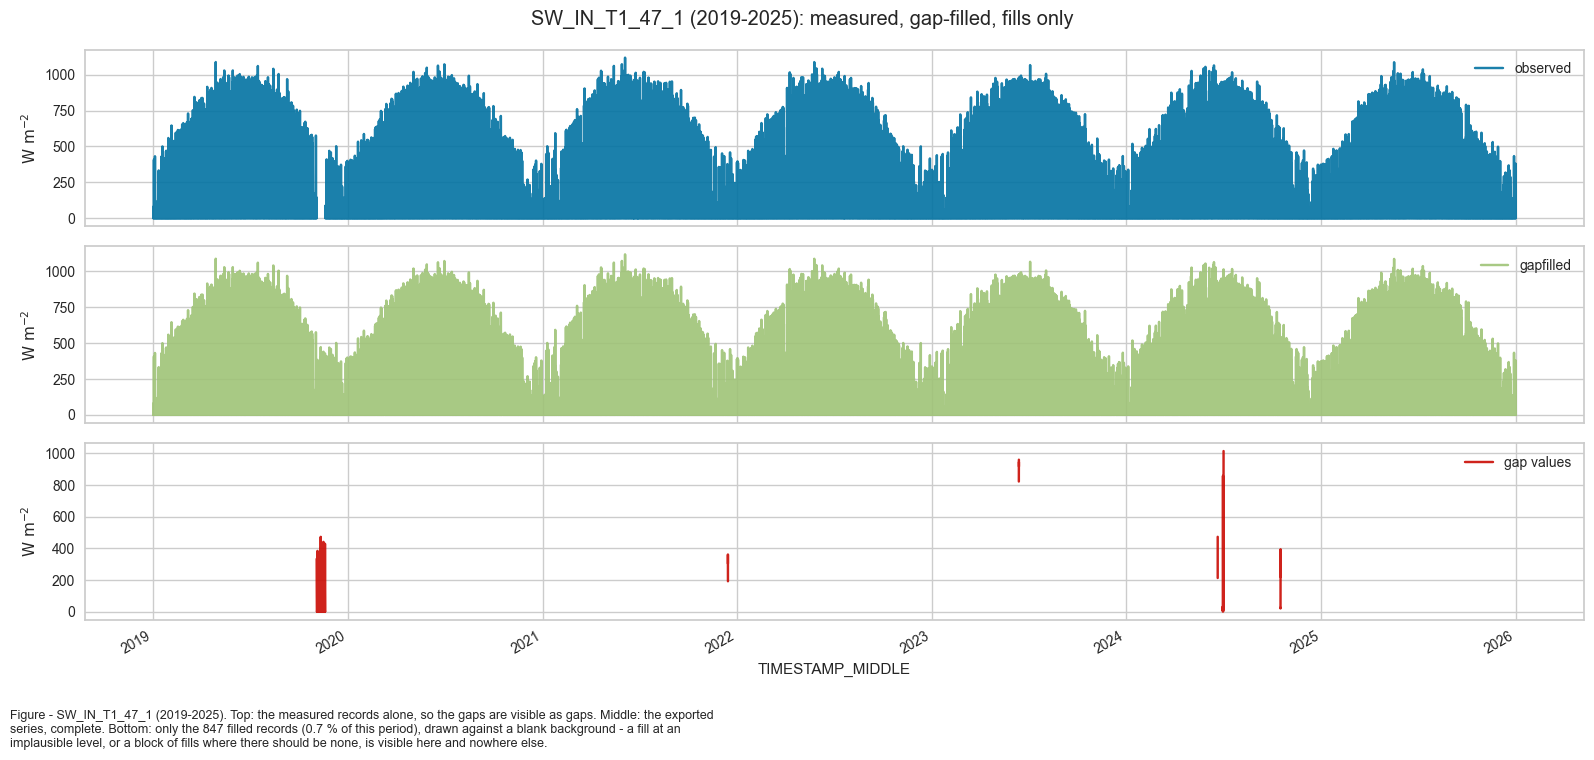

In [56]:
plot_gapfill_panels(gf_eth_2019_2025.results, label="SW_IN_T1_47_1 (2019-2025)");

#### Plot: predicted vs measured on held-out data

The model never saw these records during training, so this is the view that shows whether the
daytime model is actually any good. A tilt in the residual panel means bias; a widening cone means
the error grows with the value, which for radiation is expected.

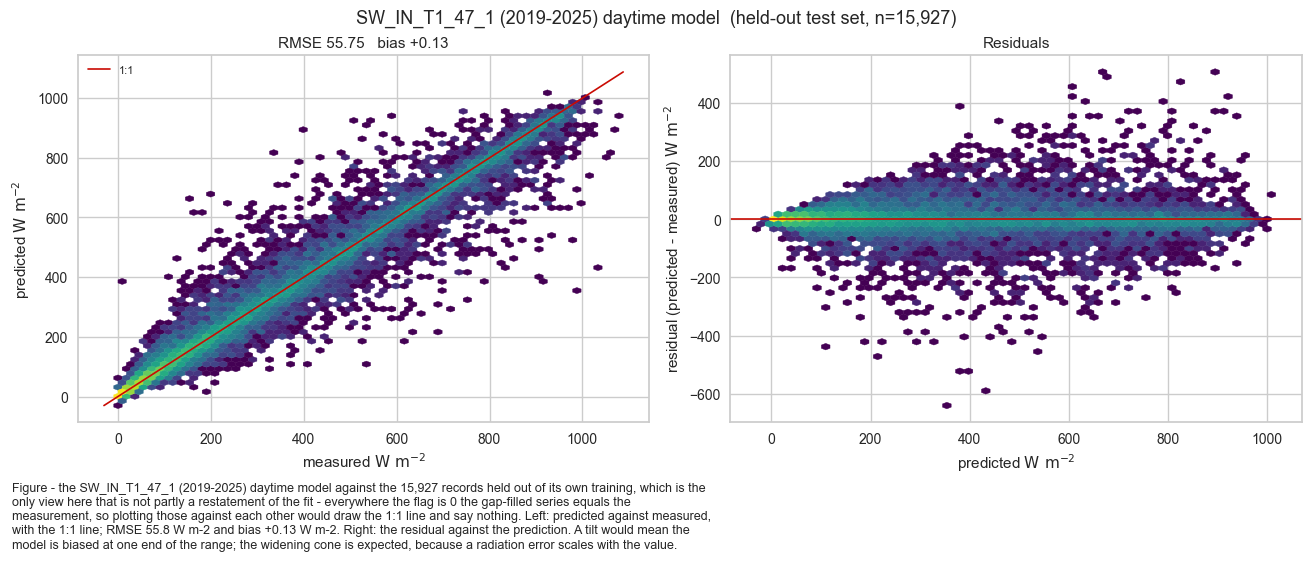

In [57]:
plot_pred_vs_measured(gf_eth_2019_2025.daytime_model_, label="SW_IN_T1_47_1 (2019-2025)");

### Plot time series

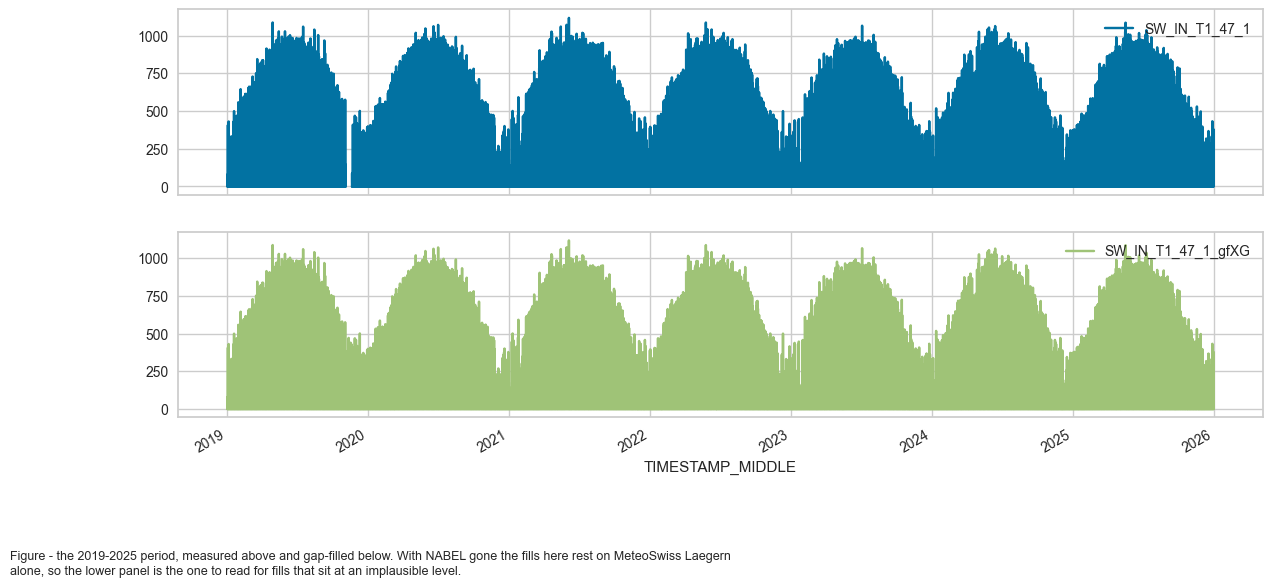

In [58]:
_axs = swin_2019_2025[[TARGET, gapfilled_eth_2019_2025.name]].plot(
    subplots=True, x_compat=True, figsize=(14, 6))
figcap(_axs[0].get_figure(), "the 2019-2025 period, measured above and gap-filled below. "
                             "With NABEL gone the fills here rest on MeteoSwiss Laegern "
                             "alone, so the lower panel is the one to read for fills that "
                             "sit at an implausible level.");

### Dataframe

In [59]:
tabcap("the 2019-2025 frame with its gap-filled column added")
display(swin_2019_2025)
swin_2019_2025.describe()

Table - the 2019-2025 frame with its gap-filled column added



,SW_IN_T1_47_1,SW_IN_LAE_MS,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,
2019-01-01 00:15:00,0.0,2.333333,0.0
2019-01-01 00:45:00,0.0,2.000000,0.0
2019-01-01 01:15:00,0.0,2.000000,0.0
2019-01-01 01:45:00,0.0,2.000000,0.0
2019-01-01 02:15:00,0.0,2.000000,0.0
...,...,...,...
2025-12-31 21:45:00,0.0,2.333333,0.0
2025-12-31 22:15:00,0.0,2.000000,0.0
2025-12-31 22:45:00,0.0,1.666667,0.0


,SW_IN_T1_47_1,SW_IN_LAE_MS,SW_IN_T1_47_1_gfXG
count,121889.000000,122734.000000,122736.000000
mean,149.817717,145.210102,149.352257
std,245.046332,235.775359,244.630334
min,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000
50%,3.723554,5.666667,3.638556
75%,205.228608,196.666667,204.050755
max,1118.658439,1136.000000,1118.658439


***

## ➡️ Prepare dataframe for export

In [60]:
VALCOL = "SW_IN_T1_47_1_gfXG"
FLAGCOL = "FLAG_SW_IN_T1_47_1_ISFILLED"

# Values and flags come from the same gap-filling run per period, so they are paired
# before the two periods are stacked.
export_df = pd.concat([
    pd.concat([swin_2004_2018[VALCOL], flag_eth_2004_2018], axis=1),
    pd.concat([swin_2019_2025[VALCOL], flag_eth_2019_2025], axis=1),
], axis=0)
tabcap("the two gap-filled periods stacked into the frame that is exported")
export_df

Table - the two gap-filled periods stacked into the frame that is exported



,SW_IN_T1_47_1_gfXG,FLAG_SW_IN_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,3
2004-01-01 00:45:00,0.0,3
2004-01-01 01:15:00,0.0,3
2004-01-01 01:45:00,0.0,3
2004-01-01 02:15:00,0.0,3
...,...,...
2025-12-31 21:45:00,0.0,0
2025-12-31 22:15:00,0.0,0
2025-12-31 22:45:00,0.0,0


Sanity check: the exported series must be complete (no gaps) and non-negative, the index must be
continuous 30MIN with no duplicates, and every record must carry a flag.

`FLAG_SW_IN_T1_47_1_ISFILLED` travels with the product so the downstream notebooks can tell
measured from filled records. Flag `0` is measured, everything above `0` is filled by the method
given in `FLAG_LEGEND`.

In [61]:
print(f"Records:         {len(export_df)}")
print(f"Missing values:  {export_df[VALCOL].isnull().sum()}")
print(f"Negative values: {(export_df[VALCOL] < 0).sum()}")
print(f"Missing flags:   {export_df[FLAGCOL].isnull().sum()}")
print(f"Duplicate index: {export_df.index.duplicated().sum()}")
print(f"Index gaps:      {(export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum()}")

print("\nFill provenance:")
_counts = export_df[FLAGCOL].value_counts().sort_index()
_pct = 100 * _counts / len(export_df)
tabcap("the provenance of every record in the exported product. Code 3 is a nighttime gap set to zero by physics rather than an estimate, so codes 0 and 3 together are the share of the product that no model produced")
display(pd.DataFrame({'count': _counts, '%': _pct.round(2)}).rename(index=FLAG_LEGEND))
print(f"Measured: {100 * (export_df[FLAGCOL] == 0).mean():.2f}%  |  "
      f"Filled: {100 * (export_df[FLAGCOL] > 0).mean():.2f}%")

tabcap("summary statistics of the exported product")
export_df.describe()

# The exported series is complete, so every nighttime record must be exactly zero --
# not merely non-negative. This is the end-to-end version of the check made before
# gap-filling, and it also covers the values the gap-filler itself wrote.
_dnf_out = dv.variables.DaytimeNighttimeFlag(
    timestamp_index=export_df.index,
    nighttime_threshold=0.001,
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)
_night_out = _dnf_out.get_nighttime_flag() == 1
_bad_night = int((export_df.loc[_night_out, VALCOL] != 0).sum())
_bad_neg = int((export_df[VALCOL] < 0).sum())
print(f"Nighttime non-zero:  {_bad_night}")
print(f"Negative values:     {_bad_neg}")
assert _bad_night == 0, f'{_bad_night} exported nighttime records are not zero'
assert _bad_neg == 0, f'{_bad_neg} exported records are negative'
print("Nighttime/negativity checks passed.")

Records:         385728
Missing values:  0
Negative values: 0
Missing flags:   0
Duplicate index: 0
Index gaps:      0

Fill provenance:
Table - the provenance of every record in the exported product. Code 3 is a nighttime gap set to
zero by physics rather than an estimate, so codes 0 and 3 together are the share of the product that
no model produced



,count,%
FLAG_SW_IN_T1_47_1_ISFILLED,,
0 = observed,351726,91.18
"1 = daytime gap, filled by the XGBoost model",17411,4.51
"2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)",697,0.18
"3 = nighttime gap, set to zero by physics",15894,4.12


Measured: 91.18%  |  Filled: 8.82%
Table - summary statistics of the exported product



Nighttime non-zero:  0
Negative values:     0
Nighttime/negativity checks passed.


### Gap-filling overview

Where the fills sit in the record, and whether they behave like the measured data. In the monthly
means panel the two lines should track each other; a systematic gap between them means the fills
are biased relative to the measurements.

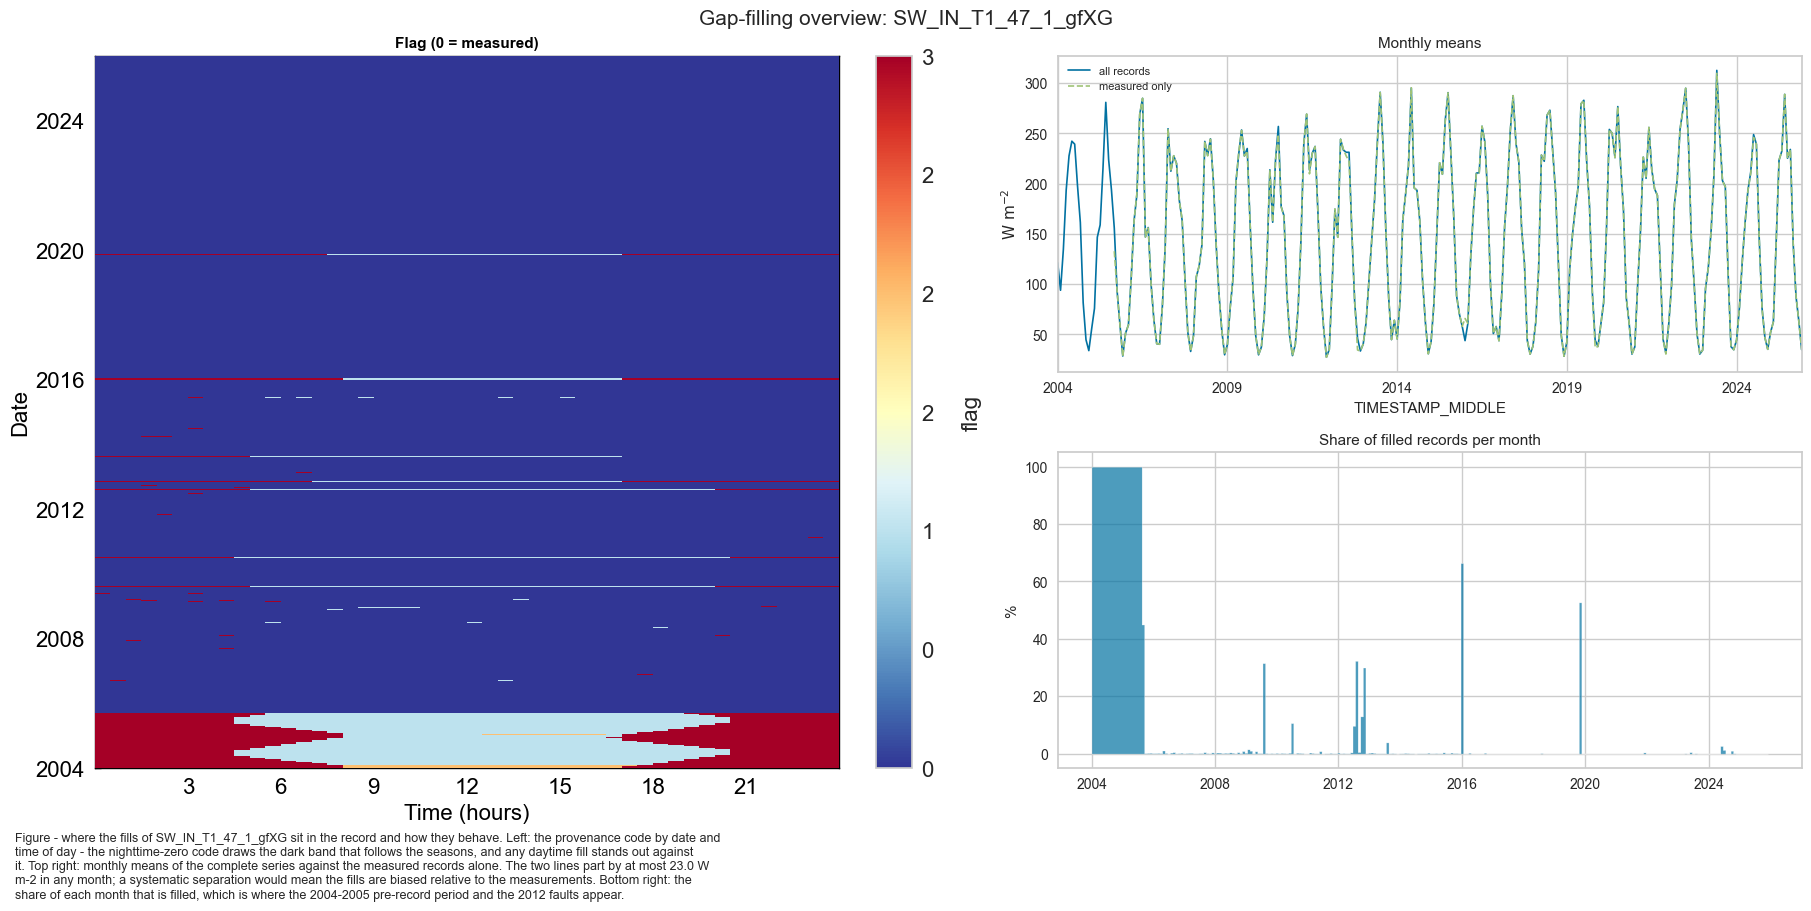

In [62]:
plot_fill_overview(export_df[VALCOL], export_df[FLAGCOL], label=VALCOL);

### Fill statistics per year

The table counts records per year and flag; the bars show the filled ones only. This is where an
uneven distribution of fills across the record becomes obvious.

Table - records per year and provenance code for SW_IN_T1_47_1_gfXG. Every record carries a code, so
the rows sum to the number of half-hours in each year



,0 = observed,"1 = daytime gap, filled by the XGBoost model","2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)","3 = nighttime gap, set to zero by physics"
year,,,,
2004,0,8571,598,8399
2005,5199,6863,56,5402
2006,17473,17,0,30
2007,17489,15,0,16
2008,17513,27,0,28
2009,16989,310,0,221
2010,17339,119,0,62
2011,17491,8,9,12
2012,16293,637,29,609


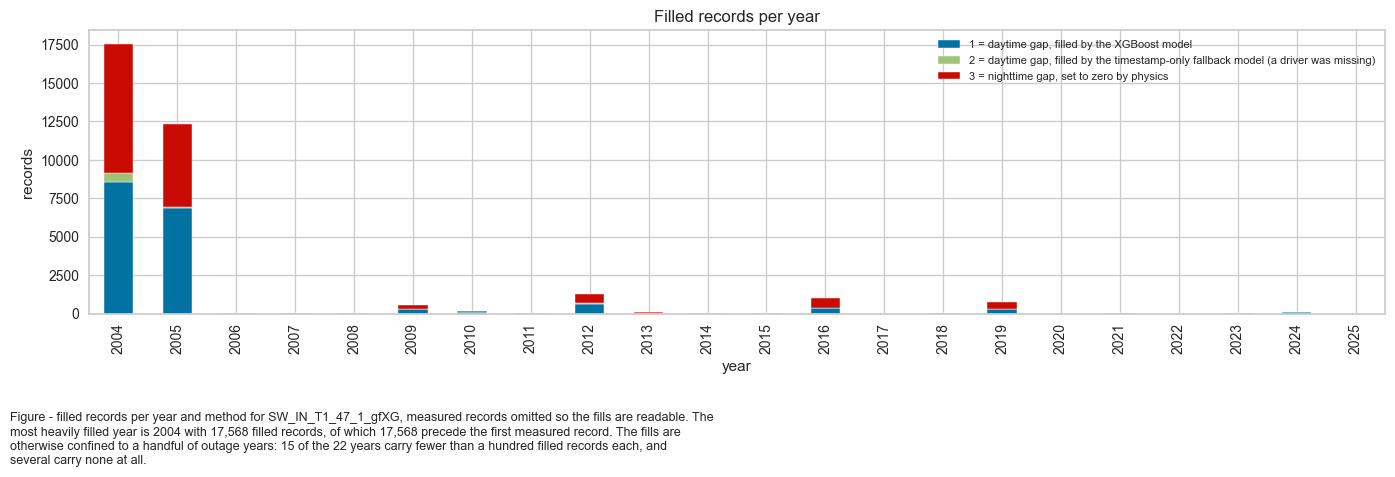

In [63]:
fill_stats_by_year(export_df[FLAGCOL], label=VALCOL)

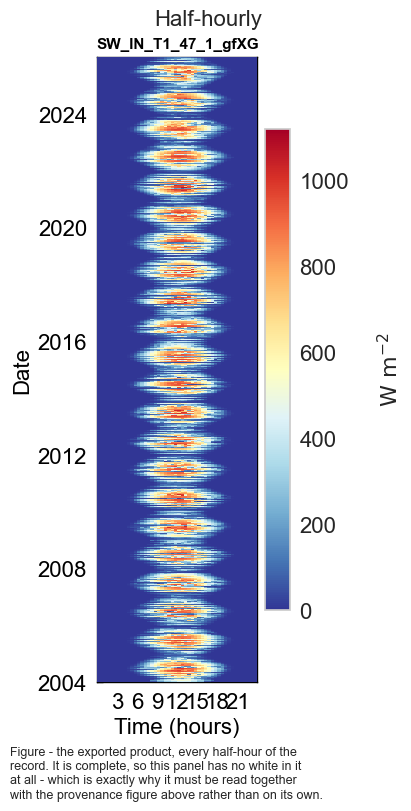

In [64]:
fig, axs = plt.subplots(ncols=1, figsize=(4, 8), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=axs, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))
figcap(fig, "the exported product, every half-hour of the record. It is complete, so this panel "
            "has no white in it at all - which is exactly why it must be read together with the "
            "provenance figure above rather than on its own.")

### The exported product

Two views of the finished series that the diagnostics above do not give: the shape of the average
day through the year, and whether the values are physically possible.

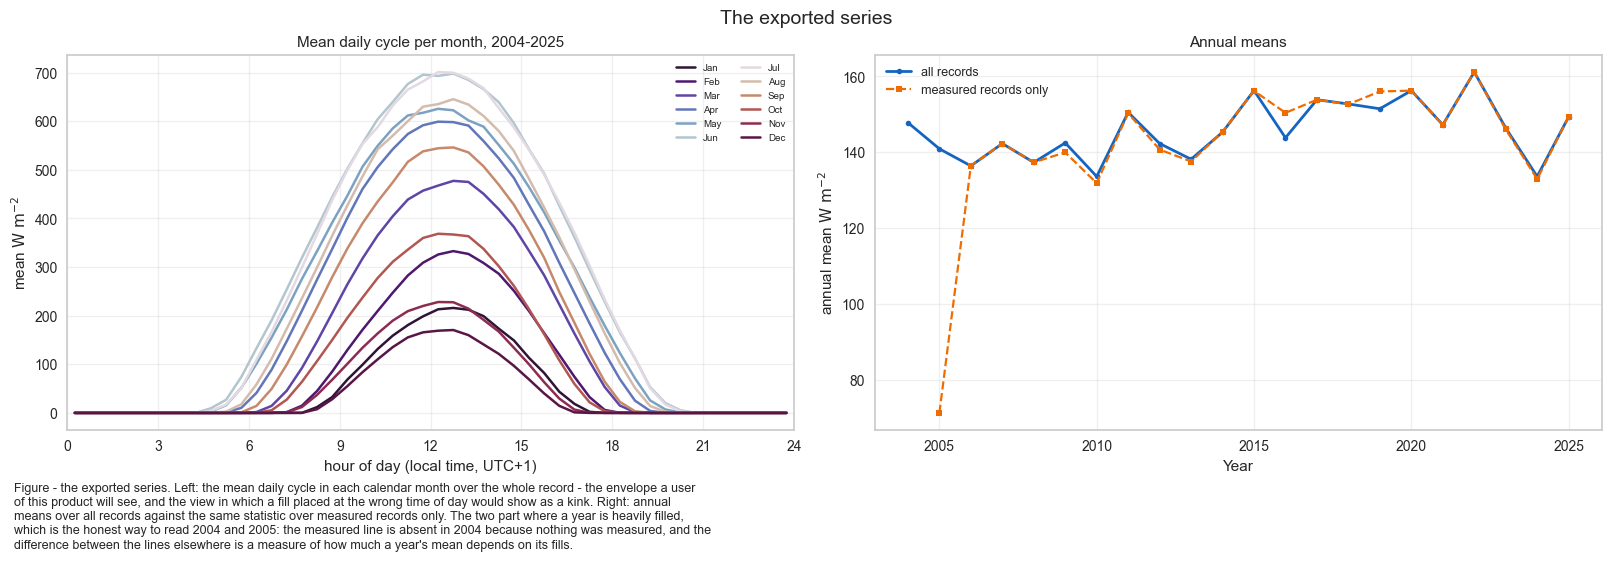

In [65]:
# The average day, month by month, and the annual cycle. This is the shape a user of the product
# will actually see, and a fill that sat at the wrong time of day would distort it.
_pot_out = dv.variables.potrad(timestamp_index=export_df.index, lat=SITE_LAT, lon=SITE_LON,
                               utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
_d = pd.DataFrame({'v': export_df[VALCOL], 'flag': export_df[FLAGCOL], 'pot': _pot_out})
_d['hour'] = _d.index.hour + _d.index.minute / 60
_d['month'] = _d.index.month

fig, axs = plt.subplots(ncols=2, figsize=(16, 5.5), dpi=100, layout='constrained')
fig.suptitle('The exported series', fontsize=14)

_comp = _d.pivot_table(index='hour', columns='month', values='v', aggfunc='mean')
_cmap = plt.get_cmap('twilight_shifted')
for _m in _comp.columns:
    axs[0].plot(_comp.index, _comp[_m], color=_cmap((_m - 1) / 12), lw=1.8,
                label=pd.Timestamp(2020, _m, 1).strftime('%b'))
axs[0].set_xlabel('hour of day (local time, UTC+1)')
axs[0].set_ylabel(r'mean $\mathrm{W\ m^{-2}}$')
axs[0].set_xlim(0, 24)
axs[0].set_xticks(range(0, 25, 3))
axs[0].set_title('Mean daily cycle per month, 2004-2025', fontsize=11)
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=7, ncol=2)

_ann = _d['v'].resample('YE').mean()
_ann.index = _ann.index.year
_ann_meas = _d['v'].where(_d['flag'] == 0).resample('YE').mean()
_ann_meas.index = _ann_meas.index.year
axs[1].plot(_ann.index, _ann, color='#1565C0', lw=2, marker='o', ms=4, label='all records')
axs[1].plot(_ann_meas.index, _ann_meas, color='#EF6C00', lw=1.6, ls='--', marker='s', ms=4,
            label='measured records only')
axs[1].set_xlabel('Year')
axs[1].set_ylabel(r'annual mean $\mathrm{W\ m^{-2}}$')
axs[1].set_title('Annual means', fontsize=11)
axs[1].grid(alpha=0.3)
axs[1].legend(fontsize=9)

figcap(fig, "the exported series. Left: the mean daily cycle in each calendar month over the "
            "whole record - the envelope a user of this product will see, and the view in which "
            "a fill placed at the wrong time of day would show as a kink. Right: annual means "
            "over all records against the same statistic over measured records only. The two "
            "part where a year is heavily filled, which is the honest way to read 2004 and 2005: "
            "the measured line is absent in 2004 because nothing was measured, and the "
            "difference between the lines elsewhere is a measure of how much a year's mean "
            "depends on its fills.")

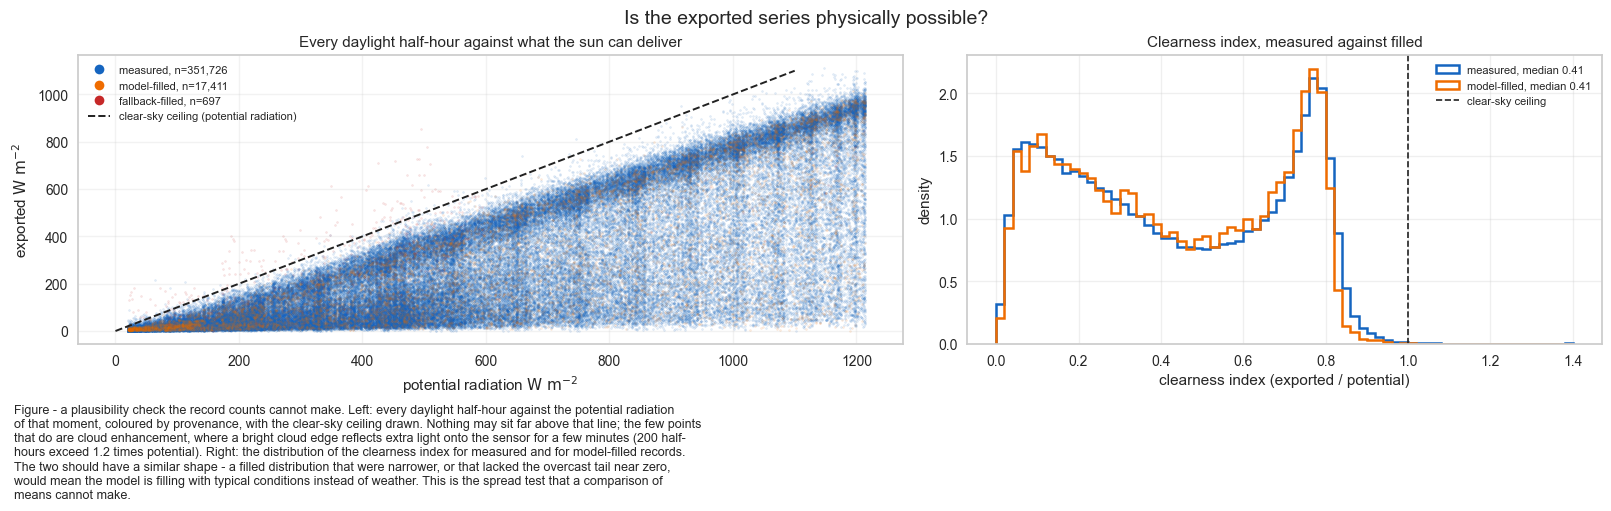

In [66]:
# A physical-plausibility check the flag counts cannot make: no half-hour may exceed what the sun
# can deliver at this latitude by more than cloud enhancement allows, and none may be negative.
_kt = (_d['v'] / _d['pot']).where(_d['pot'] > 20)
fig, axs = plt.subplots(ncols=2, figsize=(16, 5), dpi=100, layout='constrained',
                        width_ratios=[1.3, 1])
fig.suptitle('Is the exported series physically possible?', fontsize=14)

_lit_plot = _d[_d['pot'] > 20]
_sample = _lit_plot.sample(min(120_000, len(_lit_plot)), random_state=42)
for _flagval, _colour, _lab in [(0, '#1565C0', 'measured'), (1, '#EF6C00', 'model-filled'),
                                (2, '#C62828', 'fallback-filled')]:
    _s = _sample[_sample['flag'] == _flagval]
    if len(_s):
        axs[0].scatter(_s['pot'], _s['v'], s=2, alpha=0.12, color=_colour, rasterized=True)
        axs[0].plot([], [], 'o', color=_colour, label=f'{_lab}, n={int((_d["flag"] == _flagval).sum()):,}')
axs[0].plot([0, 1100], [0, 1100], color='#212121', lw=1.4, ls='--',
            label='clear-sky ceiling (potential radiation)')
axs[0].set_xlabel(r'potential radiation $\mathrm{W\ m^{-2}}$')
axs[0].set_ylabel(r'exported $\mathrm{W\ m^{-2}}$')
axs[0].set_title('Every daylight half-hour against what the sun can deliver', fontsize=11)
axs[0].legend(fontsize=8, loc='upper left')
axs[0].grid(alpha=0.25)

for _flagval, _colour, _lab in [(0, '#1565C0', 'measured'), (1, '#EF6C00', 'model-filled')]:
    _s = _kt[_d['flag'] == _flagval].dropna()
    if len(_s):
        axs[1].hist(_s.clip(0, 1.4), bins=np.linspace(0, 1.4, 71), histtype='step', lw=1.8,
                    density=True, color=_colour, label=f'{_lab}, median {_s.median():.2f}')
axs[1].axvline(1.0, color='#212121', lw=1.2, ls='--', label='clear-sky ceiling')
axs[1].set_xlabel('clearness index (exported / potential)')
axs[1].set_ylabel('density')
axs[1].set_title('Clearness index, measured against filled', fontsize=11)
axs[1].legend(fontsize=8)
axs[1].grid(alpha=0.3)

_over = int((_kt > 1.2).sum())
figcap(fig, "a plausibility check the record counts cannot make. Left: every daylight half-hour "
            "against the potential radiation of that moment, coloured by provenance, with the "
            "clear-sky ceiling drawn. Nothing may sit far above that line; the few points that do "
            f"are cloud enhancement, where a bright cloud edge reflects extra light onto the "
            f"sensor for a few minutes ({_over:,} half-hours exceed 1.2 times potential). "
            "Right: the distribution of the clearness index for measured and for model-filled "
            "records. The two should have a similar shape - a filled distribution that were "
            "narrower, or that lacked the overcast tail near zero, would mean the model is "
            "filling with typical conditions instead of weather. This is the spread test that "
            "a comparison of means cannot make.")

***

## 💾 Save to file

In [67]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\01_METEO_SW_IN_GAPFILLED_2004-2025.parquet (0.034 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\01_METEO_SW_IN_GAPFILLED_2004-2025.parquet


***

## End of notebook

In [68]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-29 00:10:52
Finished: 2026-07-29 00:11:54
Runtime:  00:01:01 (hh:mm:ss)
